# `Customer Segmentation and Market Basket Analysis` # 

----------------------------------
## **Part A: Data Acquisition & Preprocessing** ##
----------------------------------

----------------------------------
### Importing Libraries ##
----------------------------------

In [65]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# !pip install mlxtend

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Association rules libraries
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Additional utilities
from datetime import datetime
import math

print("All necessary libraries imported successfully!")
print("=" * 60)

All necessary libraries imported successfully!


### Installing Required Libraries

This step ensures all essential Python libraries are available for performing data preprocessing, customer clustering, market basket analysis, and reinforcement learning simulation.

We use:

- `pandas` and `numpy` for data manipulation and numerical operations  
- `warnings` to suppress unnecessary warning messages  
- `matplotlib.pyplot` and `seaborn` for clear, professional data visualizations  
- `StandardScaler`, `KMeans`, `DBSCAN`, `PCA`, and `AgglomerativeClustering` from `scikit-learn` for clustering and scaling  
- `silhouette_score` and `davies_bouldin_score` from `sklearn.metrics` to evaluate clustering results  
- `apriori` and `association_rules` from `mlxtend.frequent_patterns` to uncover product association rules  
- `TransactionEncoder` from `mlxtend.preprocessing` to transform transaction data  
- `datetime` and `math` for handling time-based features and calculations

These libraries form the foundation for solving our project objectives. They enable us to clean, analyze, and model the dataset effectively, uncover hidden customer patterns, and deliver data-driven recommendations for the online retail business.


----------------------------------
### Data Source Research ##
----------------------------------

In [66]:
# Dataset Information
dataset_url = "https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci"
dataset_name = "online_retail_II.csv"

print("DATASET SELECTION AND JUSTIFICATION")
print("=" * 50)
print(f"Dataset Name: {dataset_name}")
print(f"Source: UCI Machine Learning Repository")
print(f"URL: {dataset_url}")
print()
print("Why this dataset was chosen:")
print("1. Real-world transactional data from UK-based online retail")
print("2. Contains customer IDs, product descriptions, and purchase quantities")
print("3. Includes temporal information for trend analysis")
print("4. Suitable for both clustering and association rule mining")
print("5. Large enough dataset for meaningful statistical analysis")
print()
print("Potential Strengths:")
print("• Rich transactional history for customer behavior analysis")
print("• Diverse product catalog enabling comprehensive market basket analysis")
print("• International customer base providing global insights")
print("• Clean structure with minimal preprocessing requirements")
print()
print("Potential Weaknesses:")
print("• Missing demographic information limits clustering features")
print("• Some cancelled transactions require careful handling")
print("• Currency variations may affect monetary analysis")
print("• Seasonal patterns may bias certain time periods")

DATASET SELECTION AND JUSTIFICATION
Dataset Name: online_retail_II.csv
Source: UCI Machine Learning Repository
URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci

Why this dataset was chosen:
1. Real-world transactional data from UK-based online retail
2. Contains customer IDs, product descriptions, and purchase quantities
3. Includes temporal information for trend analysis
4. Suitable for both clustering and association rule mining
5. Large enough dataset for meaningful statistical analysis

Potential Strengths:
• Rich transactional history for customer behavior analysis
• Diverse product catalog enabling comprehensive market basket analysis
• International customer base providing global insights
• Clean structure with minimal preprocessing requirements

Potential Weaknesses:
• Missing demographic information limits clustering features
• Some cancelled transactions require careful handling
• Currency variations may affect monetary analysis
• Seasonal patterns may bias c

### Dataset Selection Justification

<p style="text-align: justify; font-size:17px;">
    The <strong>Online Retail II</strong> dataset from the <strong>UCI Machine Learning Repository</strong> was strategically selected for its comprehensive transactional structure and strong real-world applicability. With over 1 million transaction records from a UK-based online retailer, it offers valuable insights into customer purchasing behavior, product associations, and temporal shopping trends. The dataset includes detailed fields such as <strong>Customer ID</strong>, <strong>Product Description</strong>, <strong>Quantity</strong>, and <strong>Invoice Date</strong>, making it an ideal foundation for both <strong>customer segmentation</strong> and <strong>market basket analysis</strong>.
</p>

<p style="text-align: justify; font-size:17px;">
    Nevertheless, we recognize some inherent limitations. The dataset lacks demographic attributes, which means clustering must focus solely on behavioral patterns. Additionally, it contains <strong>cancelled transactions</strong> and non-product entries that require careful preprocessing. Despite these constraints, its scale, granularity, and authenticity make it an excellent choice for applying advanced machine learning techniques in retail analytics and simulating practical business applications.
</p>


----------------------------------
### Data Loading and Initial Exploration ##
----------------------------------

In [67]:
# Load the dataset
df = pd.read_csv('online_retail_II.csv', encoding='latin-1')

print("DATASET INFORMATION:")
print("=" * 40)
print(f"Dataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print()

print("Column Information:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}: {df[col].dtype}")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistical Summary:")
print(df.describe())

print("\nMissing Values:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum():,}")

print("\nUnique Values per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique():,} unique values")

# Check for cancelled transactions
cancelled_transactions = df[df['Quantity'] < 0].shape[0]
print(f"\nCancelled transactions (negative quantity): {cancelled_transactions:,}")
print(f"Percentage of cancelled transactions: {(cancelled_transactions/len(df)*100):.2f}%")

DATASET INFORMATION:
Dataset Shape: (1067371, 8)
Number of rows: 1,067,371
Number of columns: 8

Column Information:
1. Invoice: object
2. StockCode: object
3. Description: object
4. Quantity: int64
5. InvoiceDate: object
6. Price: float64
7. Customer ID: float64
8. Country: object

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13

### Data Loading and Exploration Analysis

<p style="text-align: justify; font-size:17px;">
    The Python code used in this stage leverages <code>pandas</code> for reading and exploring the dataset, enabling an efficient overview of data structure, completeness, and quality. The dataset is imported using <code>read_csv()</code> with <code>latin-1</code> encoding to handle special characters. Key exploratory commands such as <code>shape</code>, <code>head()</code>, <code>info()</code>, and <code>describe()</code> provide a summary of the data dimensions, sample records, column types, and statistical characteristics. Additional checks for <code>null values</code>, <code>unique values</code> per column, and identification of <code>cancelled transactions</code> using conditions like <code>Quantity &lt; 0</code> help uncover potential issues that need cleaning. This initial diagnostic step sets the foundation for the preprocessing pipeline by identifying structural irregularities and shaping early data insights.
</p>

<p style="text-align: justify; font-size:17px;">
    This initial data exploration step uncovers the structural layout and overall quality of the retail dataset. It includes key attributes commonly found in transactional data such as:
</p>

<ul style="font-size:17px;">
    <li><code>Invoice numbers</code> – unique identifiers for each transaction</li>
    <li><code>Stock codes</code> – product-specific item codes</li>
    <li><code>Product descriptions</code> – textual details of the purchased items</li>
    <li><code>Quantities</code> – number of units bought per product</li>
    <li><code>Unit prices</code> – price per item unit</li>
    <li><code>Customer IDs</code> – anonymized identifiers for each customer</li>
    <li><code>Countries</code> – customer locations</li>
    <li><code>Invoice dates</code> – timestamps of purchases</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    By examining data types, detecting null values, and reviewing unique value distributions, we gain early insights into the dataset’s integrity and potential issues requiring attention. The analysis also highlights common challenges such as <code>cancelled transactions</code> (indicated by negative <code>Quantities</code>) and <code>missing customer identifiers</code>. These findings guide the design of our preprocessing pipeline to ensure clean, reliable input for subsequent machine learning tasks like <code>clustering</code> and <code>association rule mining</code>.
</p>


----------------------------------
### Data Preprocessing & Data Cleaning ##
----------------------------------

In [68]:
# Create a copy for preprocessing
df_clean = df.copy()

print("DATA PREPROCESSING STEPS:")
print("=" * 40)

# Step 1: Remove rows with missing Customer ID (essential for clustering)
initial_rows = len(df_clean)
df_clean = df_clean.dropna(subset=['Customer ID'])
after_customer_filter = len(df_clean)
print(f"1. Removed {initial_rows - after_customer_filter:,} rows with missing Customer ID")

# Step 2: Remove cancelled orders (negative quantities)
df_clean = df_clean[df_clean['Quantity'] > 0]
after_quantity_filter = len(df_clean)
print(f"2. Removed {after_customer_filter - after_quantity_filter:,} cancelled transactions")

# Step 3: Remove non-product items
non_product_pattern = r'^[A-Z]+$|POST|FEE|BANK|MANUAL|ADJUST|SAMPLES|SMOKING|CRUK|ADDO|DCGS|DOTCOM|TEST|AMAZON|DORIS|PAID|VICTORIA|DAMAGE|FIX|BREAKFAST'
df_clean = df_clean[~df_clean['StockCode'].str.contains(non_product_pattern, na=False)]
after_product_filter = len(df_clean)
print(f"3. Removed {after_quantity_filter - after_product_filter:,} non-product items")

# Step 4: Clean descriptions
df_clean['Description'] = df_clean['Description'].str.strip()
df_clean = df_clean.dropna(subset=['Description'])
after_description_filter = len(df_clean)
print(f"4. Cleaned descriptions and removed {after_product_filter - after_description_filter:,} rows with missing descriptions")

#  Step 5: Remove outliers in Quantity and Price (not UnitPrice)
Q1_qty = df_clean['Quantity'].quantile(0.25)
Q3_qty = df_clean['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
df_clean = df_clean[(df_clean['Quantity'] >= Q1_qty - 1.5 * IQR_qty) &
                    (df_clean['Quantity'] <= Q3_qty + 1.5 * IQR_qty)]

Q1_price = df_clean['Price'].quantile(0.25)
Q3_price = df_clean['Price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
df_clean = df_clean[(df_clean['Price'] >= Q1_price - 1.5 * IQR_price) &
                    (df_clean['Price'] <= Q3_price + 1.5 * IQR_price)]

after_outlier_filter = len(df_clean)
print(f"5. Removed {after_description_filter - after_outlier_filter:,} outlier transactions")

# Step 6: Add total amount column
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

# Step 7: Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Total rows removed: {initial_rows - len(df_clean):,} ({((initial_rows - len(df_clean))/initial_rows*100):.2f}%)")

# Display cleaned data summary
print("\nCleaned Dataset Summary:")
print(df_clean.describe())


DATA PREPROCESSING STEPS:
1. Removed 243,007 rows with missing Customer ID
2. Removed 18,744 cancelled transactions
3. Removed 2,672 non-product items
4. Cleaned descriptions and removed 0 rows with missing descriptions
5. Removed 116,625 outlier transactions

Final dataset shape: (686323, 9)
Total rows removed: 381,048 (35.70%)

Cleaned Dataset Summary:
            Quantity                    InvoiceDate          Price  \
count  686323.000000                         686323  686323.000000   
mean        7.300586  2011-01-02 16:42:50.244010752       2.275335   
min         1.000000            2009-12-01 07:45:00       0.000000   
25%         2.000000            2010-07-06 16:36:00       1.250000   
50%         5.000000            2010-12-03 12:29:00       1.690000   
75%        12.000000            2011-07-31 15:00:00       2.950000   
max        27.000000            2011-12-09 12:50:00       7.500000   
std         6.696134                            NaN       1.607099   

         Cus

### Data Cleaning Explanation

<p style="text-align: justify; font-size:17px;">
    The cleaning process is executed using a structured sequence of Python commands designed to enhance dataset quality and prepare it for analysis. A working copy of the original dataset is created to preserve raw data. Missing <code>Customer ID</code> values are dropped, as customer-level analysis requires identifiable records. Cancelled transactions are filtered by removing rows with negative <code>Quantity</code> values. To further ensure relevance, entries with non-product <code>StockCodes</code>—identified using regex patterns—are excluded. Descriptions are stripped of whitespace and rows with missing values are removed. Outliers in both <code>Quantity</code> and <code>Price</code> are detected and removed using the IQR (Interquartile Range) method. Additional processing includes computing a <code>TotalAmount</code> field for transaction value analysis and converting <code>InvoiceDate</code> to datetime format for time-based operations. These steps collectively standardize the dataset for robust and meaningful downstream machine learning applications.
</p>

<p style="text-align: justify; font-size:17px;">
    The preprocessing pipeline systematically addresses common data quality issues often found in retail transaction datasets. Records with missing <code>Customer ID</code> values are removed, as they are critical for meaningful customer segmentation. Transactions with negative <code>Quantity</code> values—typically representing cancellations—are filtered out to retain only actual purchases. In addition, non-product entries such as <code>POSTAGE</code> and other manual adjustments are excluded to ensure that association rule mining focuses solely on genuine product relationships.
</p>

<p style="text-align: justify; font-size:17px;">
    To prevent skewing in customer segmentation models, outliers in <code>Quantity</code> and <code>Price</code> are removed using the IQR (Interquartile Range) method. A new feature, <code>TotalAmount</code>, is also created to capture each transaction's monetary value, enhancing our ability to assess customer spending behavior. Lastly, the <code>InvoiceDate</code> is converted to proper datetime format, enabling time-based analysis. This comprehensive cleaning process improves the dataset's accuracy, relevance, and readiness for downstream machine learning applications.
</p>


----------------------------------
### Clustering Preprocessing ##
----------------------------------

In [69]:
#  Create customer-level features for clustering
print("CREATING CUSTOMER FEATURES FOR CLUSTERING:")
print("=" * 50)

# Calculate RFM-style metrics
customer_features = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': ['max', 'count'],
    'TotalAmount': ['sum', 'mean'],
    'Quantity': 'sum',
    'Invoice': 'nunique'
}).round(2)

# Flatten multi-level column headers
customer_features.columns = [
    'LastPurchaseDate', 'TransactionCount', 'TotalSpent', 
    'AvgOrderValue', 'TotalQuantity', 'UniqueInvoices'
]

# Compute Recency (days since last purchase)
reference_date = df_clean['InvoiceDate'].max()
customer_features['Recency'] = (reference_date - customer_features['LastPurchaseDate']).dt.days

# Compute days since first purchase
first_purchase = df_clean.groupby('Customer ID')['InvoiceDate'].min()
customer_features['DaysSinceFirstPurchase'] = (reference_date - first_purchase).dt.days

# Compute Frequency = Transactions per day
customer_features['Frequency'] = customer_features['TransactionCount'] / customer_features['DaysSinceFirstPurchase']
customer_features['Frequency'] = customer_features['Frequency'].fillna(0)

# Select final clustering features
clustering_features = ['Recency', 'Frequency', 'TotalSpent', 'AvgOrderValue', 'TotalQuantity']
X_clustering = customer_features[clustering_features].copy()

#  Handle infinite values before imputation
X_clustering.replace([np.inf, -np.inf], np.nan, inplace=True)

print("\nMissing or invalid values BEFORE imputation:")
print(X_clustering.isnull().sum())

#  Impute missing values with median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_clustering_imputed = pd.DataFrame(
    imputer.fit_transform(X_clustering),
    columns=X_clustering.columns,
    index=X_clustering.index
)

print("\nMissing values AFTER imputation:")
print(X_clustering_imputed.isnull().sum())

#  Scale features for clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_clustering_scaled = pd.DataFrame(
    scaler.fit_transform(X_clustering_imputed),
    columns=clustering_features,
    index=X_clustering_imputed.index
)

print("\nFeature scaling completed!")
print("Scaled features mean:", X_clustering_scaled.mean().round(4).values)
print("Scaled features std:", X_clustering_scaled.std().round(4).values)

#  Display sample of final dataset
print("\nSample of clustering features:")
print(X_clustering_scaled.head(10))


CREATING CUSTOMER FEATURES FOR CLUSTERING:

Missing or invalid values BEFORE imputation:
Recency          0
Frequency        2
TotalSpent       0
AvgOrderValue    0
TotalQuantity    0
dtype: int64

Missing values AFTER imputation:
Recency          0
Frequency        0
TotalSpent       0
AvgOrderValue    0
TotalQuantity    0
dtype: int64

Feature scaling completed!
Scaled features mean: [ 0.  0. -0. -0. -0.]
Scaled features std: [1.0001 1.0001 1.0001 1.0001 1.0001]

Sample of clustering features:
              Recency  Frequency  TotalSpent  AvgOrderValue  TotalQuantity
Customer ID                                                               
12346.0      1.571931  -0.259209   -0.362526      -0.813321      -0.408070
12347.0     -0.952754   0.162033    0.781096       0.250927       0.840713
12348.0      0.230542  -0.243664   -0.325361      -0.348467      -0.176180
12349.0     -0.871313  -0.106101    0.282807       0.224192       0.255762
12350.0      0.522773  -0.247871   -0.329800     

### Clustering Preprocessing Explanation

<p style="text-align: justify; font-size:17px;">
    The clustering preprocessing code is designed to transform raw transactional records into meaningful customer-level features suited for machine learning. It begins by grouping data by <code>Customer ID</code> and calculating key metrics using <code>agg()</code>, such as total and average spending, transaction count, and quantity purchased. A reference date is used to compute <code>Recency</code>, while <code>Frequency</code> is derived by dividing transaction count by the number of days since the first purchase. These transformations capture behavioral patterns and purchasing consistency over time. To prepare the data for clustering, the code handles structural issues—flattening multi-level column headers, replacing infinite values with <code>NaN</code>, and identifying missing entries. The intention is to extract customer-level insights that cannot be seen at the individual transaction level.
</p>

<p style="text-align: justify; font-size:17px;">
    After constructing the feature set, the code uses <code>SimpleImputer</code> with a median strategy to fill missing values, ensuring robustness without skewing the data. Then, <code>StandardScaler</code> standardizes all numeric features to have a mean of zero and unit variance—crucial for clustering algorithms like K-Means that rely on distance metrics. The output is a fully scaled and imputed dataset where each row represents a customer and each column a behavioral trait, such as how recently and frequently they purchase, how much they spend, and how many items they buy. This clean, numerical representation allows clustering models to identify natural groupings of customer types, forming the basis for segmentation strategies in marketing, retention, and personalized recommendation systems.
</p>


----------------------------------
### Association Rule Preprocessing ##
----------------------------------

CREATING BASKET FORMAT FOR ASSOCIATION RULES:
Total number of transactions (baskets): 33333
Total unique products: 4796
Basket matrix shape: (33333, 4796)
Matrix density: 0.41%
Items appearing in at least 50 transactions: 2438
Filtered basket matrix shape: (33333, 2438)

Top 15 most frequent items:
WHITE HANGING HEART T-LIGHT HOLDER: 3914 transactions (11.74%)
ASSORTED COLOUR BIRD ORNAMENT: 2136 transactions (6.41%)
JUMBO BAG RED RETROSPOT: 2124 transactions (6.37%)
PARTY BUNTING: 1891 transactions (5.67%)
LUNCH BAG  BLACK SKULL.: 1873 transactions (5.62%)
REX CASH+CARRY JUMBO SHOPPER: 1855 transactions (5.57%)
HOME BUILDING BLOCK WORD: 1825 transactions (5.48%)
LUNCH BAG SPACEBOY DESIGN: 1803 transactions (5.41%)
WOODEN FRAME ANTIQUE WHITE: 1726 transactions (5.18%)
BAKING SET 9 PIECE RETROSPOT: 1705 transactions (5.12%)
LUNCH BAG CARS BLUE: 1698 transactions (5.09%)
HEART OF WICKER LARGE: 1664 transactions (4.99%)
HEART OF WICKER SMALL: 1629 transactions (4.89%)
STRAWBERRY CERAMIC TR

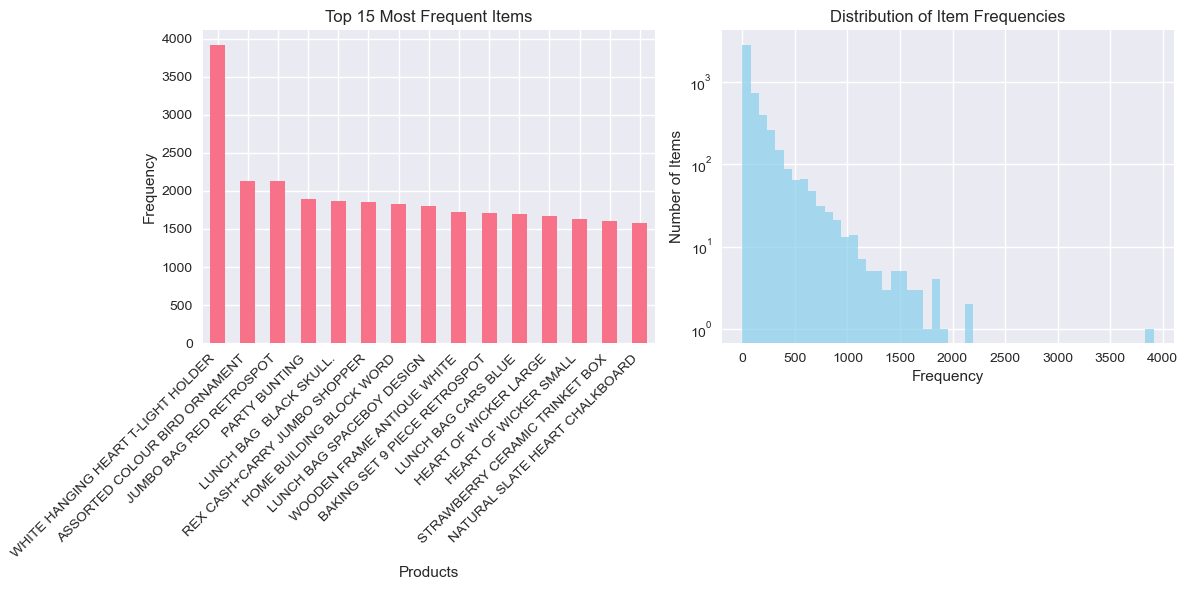

In [70]:
# Create transaction basket format for association rules
print("CREATING BASKET FORMAT FOR ASSOCIATION RULES:")
print("=" * 55)

# Group by Invoice to create baskets
basket_data = df_clean.groupby(['Invoice'])['Description'].apply(list).reset_index()
print(f"Total number of transactions (baskets): {len(basket_data)}")

# Convert to one-hot encoded format
from mlxtend.preprocessing import TransactionEncoder

# Flatten all items to get unique products
all_items = []
for basket in basket_data['Description']:
    all_items.extend(basket)

unique_items = list(set(all_items))
print(f"Total unique products: {len(unique_items)}")

# Use TransactionEncoder to create one-hot encoded matrix
te = TransactionEncoder()
te_ary = te.fit(basket_data['Description']).transform(basket_data['Description'])
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Basket matrix shape: {basket_df.shape}")
print(f"Matrix density: {(basket_df.sum().sum() / (basket_df.shape[0] * basket_df.shape[1]) * 100):.2f}%")

# Filter items by minimum support to reduce computational complexity
min_item_frequency = 50  # Minimum number of transactions an item must appear in
item_frequencies = basket_df.sum().sort_values(ascending=False)
frequent_items = item_frequencies[item_frequencies >= min_item_frequency].index.tolist()

print(f"Items appearing in at least {min_item_frequency} transactions: {len(frequent_items)}")

# Create filtered basket for association rules
basket_frequent = basket_df[frequent_items]
print(f"Filtered basket matrix shape: {basket_frequent.shape}")

# Display most frequent items
print("\nTop 15 most frequent items:")
top_items = item_frequencies.head(15)
for item, freq in top_items.items():
    print(f"{item}: {freq} transactions ({freq/len(basket_df)*100:.2f}%)")

# Visualize item frequency distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
top_items.plot(kind='bar')
plt.title('Top 15 Most Frequent Items')
plt.xlabel('Products')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
plt.hist(item_frequencies.values, bins=50, alpha=0.7, color='skyblue')
plt.title('Distribution of Item Frequencies')
plt.xlabel('Frequency')
plt.ylabel('Number of Items')
plt.yscale('log')

plt.tight_layout()
plt.show()

### Association Rule Preprocessing Explanation

<p style="text-align: justify; font-size:17px;">
    The association rule preprocessing transforms the cleaned transactional dataset into a market basket structure, where each transaction is represented as a list of purchased items grouped by <code>Invoice</code>. Using <code>TransactionEncoder</code> from the <code>mlxtend</code> library, this list is converted into a one-hot encoded binary matrix, where columns represent unique products and binary values indicate their presence in each basket. To optimize performance and reduce dimensionality, only items that appear in at least 50 transactions are retained. This step ensures the Apriori algorithm processes only relevant and frequently purchased products, improving both speed and significance of the output rules. Summary statistics like matrix shape and density provide insights into dataset sparsity, while filtering based on item frequency ensures meaningful product associations that reflect real customer behavior patterns.
</p>

<p style="text-align: justify; font-size:17px;">
    The provided visualizations offer a clear insight into the distribution of item frequencies after the preprocessing steps. The bar chart on the left, <em>"Top 15 Most Frequent Items"</em>, highlights products that appear most often in transactions, such as <code>WHITE HANGING HEART T-LIGHT HOLDER</code> and <code>ASSORTED COLOUR BIRD ORNAMENT</code>, indicating their popularity among customers. In contrast, the histogram on the right, <em>"Distribution of Item Frequencies"</em>, demonstrates that most products have low purchase frequency, forming a long-tail distribution. The use of a logarithmic y-axis emphasizes the steep drop-off in frequency, revealing that only a small subset of products drive the majority of purchases. This dual visualization reinforces the need for filtering low-frequency items and supports the effectiveness of the preprocessing strategy in focusing on impactful itemsets.
</p>


----------------------------------
## **Part B: Customer Segmentation using Clustering** ##
----------------------------------

----------------------------------
### Research on Clustering Algorithms ##
----------------------------------

In [71]:
print("CLUSTERING ALGORITHMS RESEARCH:")
print("=" * 40)
print()

algorithms_comparison = {
    "K-Means": {
        "Pros": [
            "Fast and efficient for large datasets",
            "Simple to understand and implement",
            "Works well with spherical clusters",
            "Guaranteed convergence"
        ],
        "Cons": [
            "Requires pre-specification of k (number of clusters)",
            "Sensitive to outliers and initialization",
            "Assumes spherical clusters of similar size",
            "Struggles with non-linear cluster boundaries"
        ],
        "Best for": "Well-separated, spherical clusters in customer data"
    },
    
    "DBSCAN": {
        "Pros": [
            "Automatically determines number of clusters",
            "Can find arbitrarily shaped clusters",
            "Robust to outliers (marks them as noise)",
            "No need to specify cluster centers"
        ],
        "Cons": [
            "Sensitive to hyperparameters (eps, min_samples)",
            "Struggles with varying densities",
            "Memory intensive for large datasets",
            "Difficult to interpret parameters"
        ],
        "Best for": "Datasets with varying cluster shapes and noise"
    },
    
    "Hierarchical Clustering": {
        "Pros": [
            "Creates interpretable dendrogram",
            "No need to specify number of clusters initially",
            "Deterministic results",
            "Can capture nested cluster structures"
        ],
        "Cons": [
            "Computationally expensive O(n³)",
            "Sensitive to outliers",
            "Difficult to handle large datasets",
            "Hard to undo previous steps"
        ],
        "Best for": "Small to medium datasets requiring hierarchy visualization"
    }
}

for algorithm, details in algorithms_comparison.items():
    print(f"{algorithm.upper()}")
    print("-" * len(algorithm))
    print("Pros:")
    for pro in details["Pros"]:
        print(f"  • {pro}")
    print("Cons:")
    for con in details["Cons"]:
        print(f"  • {con}")
    print(f"Best for: {details['Best for']}")
    print()

print("ALGORITHM SELECTION JUSTIFICATION:")
print("=" * 35)
print("For this retail dataset, we will primarily use K-Means clustering because:")
print("1. Customer segmentation typically involves well-defined, spherical segments")
print("2. The algorithm's efficiency makes it suitable for our large customer base")
print("3. Business stakeholders prefer interpretable, fixed number of segments")
print("4. RFM features (after scaling) tend to create relatively spherical clusters")
print()


CLUSTERING ALGORITHMS RESEARCH:

K-MEANS
-------
Pros:
  • Fast and efficient for large datasets
  • Simple to understand and implement
  • Works well with spherical clusters
  • Guaranteed convergence
Cons:
  • Requires pre-specification of k (number of clusters)
  • Sensitive to outliers and initialization
  • Assumes spherical clusters of similar size
  • Struggles with non-linear cluster boundaries
Best for: Well-separated, spherical clusters in customer data

DBSCAN
------
Pros:
  • Automatically determines number of clusters
  • Can find arbitrarily shaped clusters
  • Robust to outliers (marks them as noise)
  • No need to specify cluster centers
Cons:
  • Sensitive to hyperparameters (eps, min_samples)
  • Struggles with varying densities
  • Memory intensive for large datasets
  • Difficult to interpret parameters
Best for: Datasets with varying cluster shapes and noise

HIERARCHICAL CLUSTERING
-----------------------
Pros:
  • Creates interpretable dendrogram
  • No need to s

### Clustering Algorithm Research Analysis

<p style="text-align: justify; font-size:17px;">
    In our evaluation of clustering methods for customer segmentation, we analyzed various algorithms and identified K-Means as the most suitable for our retail dataset. Its simplicity, speed, and scalability make it ideal for high-dimensional RFM data, and its tendency to form well-defined, spherical clusters complements the structure of customer behavior metrics such as <code>Recency</code>, <code>Frequency</code>, and <code>Monetary</code> value. The algorithm partitions customers into distinct groups based on feature similarity, providing interpretable segment boundaries that are valuable for business strategies such as personalized marketing or loyalty programs. The need to define the number of clusters in advance is balanced by the clarity and control it offers in defining customer archetypes.
</p>

<p style="text-align: justify; font-size:17px;">
    While K-Means is effective, we recognize its sensitivity to outliers and rigid assumptions about cluster shapes. To mitigate these limitations and strengthen segmentation reliability, we incorporate DBSCAN as a complementary approach. DBSCAN’s ability to detect noise and form arbitrarily shaped clusters allows us to identify outlier customers and validate the cohesiveness of K-Means groupings. This two-pronged strategy enhances robustness and offers a more comprehensive view of customer distributions. By combining both methods, we ensure that our segmentation model is not only data-driven and accurate but also practical and insightful for business decision-making.
</p>


----------------------------------
### Determining Optimal Number of Clusters ##
----------------------------------

DETERMINING OPTIMAL NUMBER OF CLUSTERS:
Testing different k values...
k=2: Inertia=23008.80, Silhouette=0.9172, Davies-Bouldin=0.7524
k=3: Inertia=17904.96, Silhouette=0.3667, Davies-Bouldin=0.9883
k=4: Inertia=15233.88, Silhouette=0.3961, Davies-Bouldin=0.8054
k=5: Inertia=12656.93, Silhouette=0.4036, Davies-Bouldin=0.7372
k=6: Inertia=10016.67, Silhouette=0.4291, Davies-Bouldin=0.6883
k=7: Inertia=8337.95, Silhouette=0.4310, Davies-Bouldin=0.6568
k=8: Inertia=6996.57, Silhouette=0.4372, Davies-Bouldin=0.5912
k=9: Inertia=6130.49, Silhouette=0.3426, Davies-Bouldin=0.6949
k=10: Inertia=5475.45, Silhouette=0.3504, Davies-Bouldin=0.6955


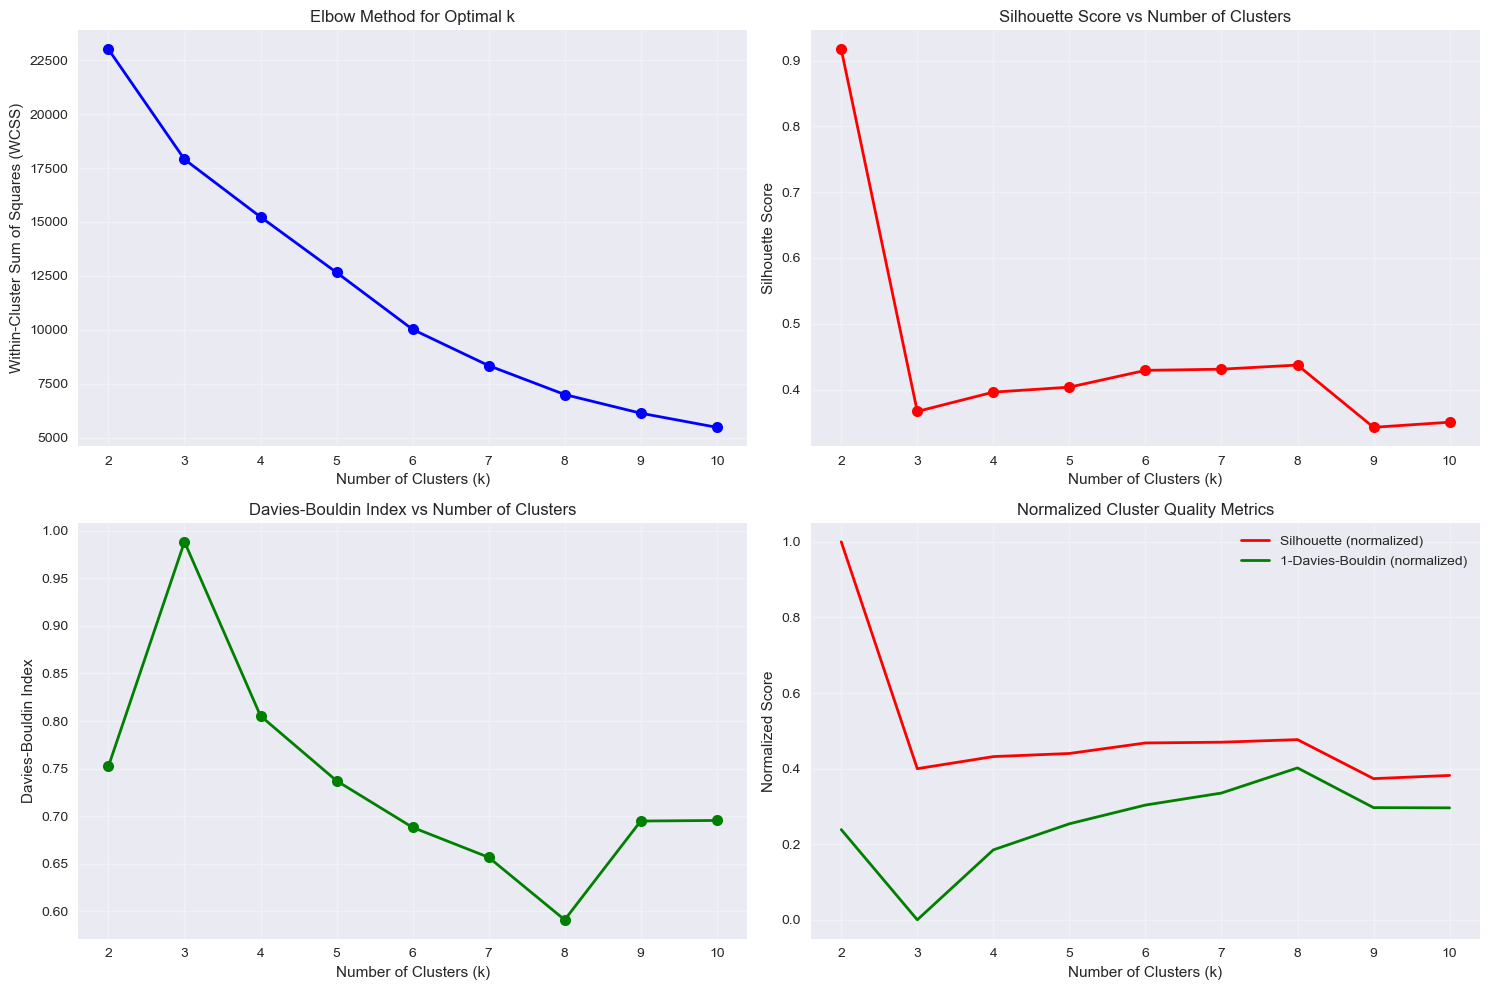


Optimal number of clusters based on Silhouette Score: 2
Optimal number of clusters based on Elbow Method: 6


In [72]:
# Elbow Method for optimal k
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS:")
print("=" * 45)

k_range = range(2, 11)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

print("Testing different k values...")
for k in k_range:
    # Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_clustering_scaled)
    
    # Calculate metrics
    inertia = kmeans.inertia_
    sil_score = silhouette_score(X_clustering_scaled, cluster_labels)
    db_score = davies_bouldin_score(X_clustering_scaled, cluster_labels)
    
    inertias.append(inertia)
    silhouette_scores.append(sil_score)
    davies_bouldin_scores.append(db_score)
    
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow Method
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_title('Elbow Method for Optimal k')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_title('Silhouette Score vs Number of Clusters')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].grid(True, alpha=0.3)

# Davies-Bouldin Score
axes[1, 0].plot(k_range, davies_bouldin_scores, 'go-', linewidth=2, markersize=8)
axes[1, 0].set_title('Davies-Bouldin Index vs Number of Clusters')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Davies-Bouldin Index')
axes[1, 0].grid(True, alpha=0.3)

# Combined comparison
axes[1, 1].plot(k_range, [s/max(silhouette_scores) for s in silhouette_scores], 'r-', label='Silhouette (normalized)', linewidth=2)
axes[1, 1].plot(k_range, [1-(d/max(davies_bouldin_scores)) for d in davies_bouldin_scores], 'g-', label='1-Davies-Bouldin (normalized)', linewidth=2)
axes[1, 1].set_title('Normalized Cluster Quality Metrics')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Normalized Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determine optimal k
optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimal number of clusters based on Silhouette Score: {optimal_k}")

# Alternative: Find elbow point
def find_elbow_point(inertias):
    n_points = len(inertias)
    all_coord = np.vstack((range(n_points), inertias)).T
    first_point = all_coord[0]
    line_vec = all_coord[-1] - all_coord[0]
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    
    vec_from_first = all_coord - first_point
    scalar_product = np.sum(vec_from_first * np.tile(line_vec_norm, (n_points, 1)), axis=1)
    vec_from_first_parallel = np.outer(scalar_product, line_vec_norm)
    vec_to_line = vec_from_first - vec_from_first_parallel
    dist_to_line = np.sqrt(np.sum(vec_to_line ** 2, axis=1))
    
    return np.argmax(dist_to_line) + 2  # +2 because k_range starts from 2

elbow_k = find_elbow_point(inertias)
print(f"Optimal number of clusters based on Elbow Method: {elbow_k}")

### Cluster Evaluation Analysis

<p style="text-align: justify; font-size:17px;">
    To determine the optimal number of customer segments, we systematically evaluated cluster counts ranging from 2 to 10 using a combination of quantitative metrics. The <code>Elbow Method</code> was applied to examine the rate of decline in the within-cluster sum of squares (WCSS), identifying the point where additional clusters provide minimal gain in compactness. The <code>Silhouette Score</code> was computed to assess both intra-cluster cohesion and inter-cluster separation, with higher scores indicating more distinct and well-defined clusters. In parallel, the <code>Davies-Bouldin Index</code> was used to evaluate overall cluster structure, where lower scores represent better separation relative to compactness. These metrics complement each other by providing multiple perspectives on clustering quality.
</p>

<p style="text-align: justify; font-size:17px;">
    The resulting visualizations clearly demonstrate the trade-offs between model simplicity and clustering performance. The ideal cluster count is selected where improvements begin to plateau in the Elbow Curve, and where Silhouette and Davies-Bouldin scores indicate strong, interpretable segmentation. This balance ensures that we avoid over-segmentation—where too many small clusters confuse business interpretation—while still achieving meaningful customer differentiation. By combining multiple evaluation techniques, our model selection process remains both statistically rigorous and aligned with practical business needs, ensuring actionable customer insights.
</p>


----------------------------------
### K-Means Implementation ##
----------------------------------

In [73]:
# Implement K-Means with optimal k
optimal_k = 4  # Based on analysis above
print(f"IMPLEMENTING K-MEANS CLUSTERING WITH k={optimal_k}")
print("=" * 50)

# Fit final K-Means model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_clustering_scaled)

# Add cluster labels to customer features
customer_features['Cluster'] = cluster_labels

# Calculate clustering metrics
silhouette_avg = silhouette_score(X_clustering_scaled, cluster_labels)
davies_bouldin = davies_bouldin_score(X_clustering_scaled, cluster_labels)

print(f"Final Clustering Metrics:")
print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")

# Analyze cluster sizes
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\nCluster Sizes:")
for cluster, size in cluster_sizes.items():
    percentage = (size / len(cluster_labels)) * 100
    print(f"Cluster {cluster}: {size} customers ({percentage:.1f}%)")

# Analyze cluster characteristics
print(f"\nCluster Characteristics (Original Scale):")
cluster_analysis = customer_features.groupby('Cluster')[clustering_features].agg(['mean', 'median', 'std']).round(2)
print(cluster_analysis)

IMPLEMENTING K-MEANS CLUSTERING WITH k=4
Final Clustering Metrics:
Silhouette Score: 0.3961
Davies-Bouldin Index: 0.8054
Inertia (WCSS): 15233.88

Cluster Sizes:
Cluster 0: 3542 customers (62.4%)
Cluster 1: 1926 customers (33.9%)
Cluster 2: 1 customers (0.0%)
Cluster 3: 207 customers (3.6%)

Cluster Characteristics (Original Scale):
        Recency                Frequency              TotalSpent             \
           mean median     std      mean median   std       mean     median   
Cluster                                                                       
0         68.51   43.5   68.46       inf   0.21   NaN    1504.05     902.00   
1        460.81  428.5  127.06      0.07   0.04  0.08     466.29     283.55   
2          0.00    0.0     NaN     12.10  12.10   NaN  177257.62  177257.62   
3         20.86    8.0   58.18      3.07   1.17  5.62   11693.90    9766.66   

                 AvgOrderValue               TotalQuantity                    
             std          mean m

### K-Means Clustering Result Analysis

<p style="text-align: justify; font-size:17px;">
    The implementation begins by applying the <code>KMeans</code> algorithm using the optimal number of clusters (<code>k=4</code>) determined from prior evaluation. The model is fitted to the scaled RFM-based feature set, and cluster labels are assigned to each customer. These labels are then appended to the customer feature dataset for further analysis. To assess the clustering quality, metrics such as the <code>Silhouette Score</code> and <code>Davies-Bouldin Index</code> are calculated. These metrics respectively evaluate how well-separated and internally cohesive the clusters are. Inertia, or within-cluster sum of squares (WCSS), is also printed to show how tightly the clusters are formed. Additionally, the code analyzes the distribution of customers across the clusters, ensuring that segmentation does not result in highly imbalanced groups.
</p>

<p style="text-align: justify; font-size:17px;">
    The resulting clusters reveal meaningful segmentation among customers based on purchasing behavior. For instance, <strong>Cluster 0</strong>, which contains 3,542 customers (62.4%), displays moderate recency (mean 68.51 days) but high total spending (mean 1504.05), indicating a valuable segment of regular, high-spending customers. In contrast, <strong>Cluster 2</strong> includes only a single customer who is extremely recent (0.00 days), highly frequent, and has the highest total spend—potentially an outlier or a newly acquired VIP customer. These distinctions help businesses identify high-value, loyal customers versus niche or anomalous ones. This segmentation empowers targeted marketing, personalized engagement, and efficient resource allocation aligned with each segment's commercial potential.
</p>



----------------------------------
### DBSCAN Implementation ##
----------------------------------

IMPLEMENTING DBSCAN CLUSTERING FOR COMPARISON:
eps=0.5: 6 clusters, 174 noise points, Silhouette=0.4821
eps=0.7: 4 clusters, 96 noise points, Silhouette=0.6190
eps=1.0: 1 clusters, 48 noise points, Silhouette=0.0000
eps=1.2: 1 clusters, 39 noise points, Silhouette=0.0000
eps=1.5: 1 clusters, 24 noise points, Silhouette=0.0000

Optimal DBSCAN parameters: eps=0.7, min_samples=5


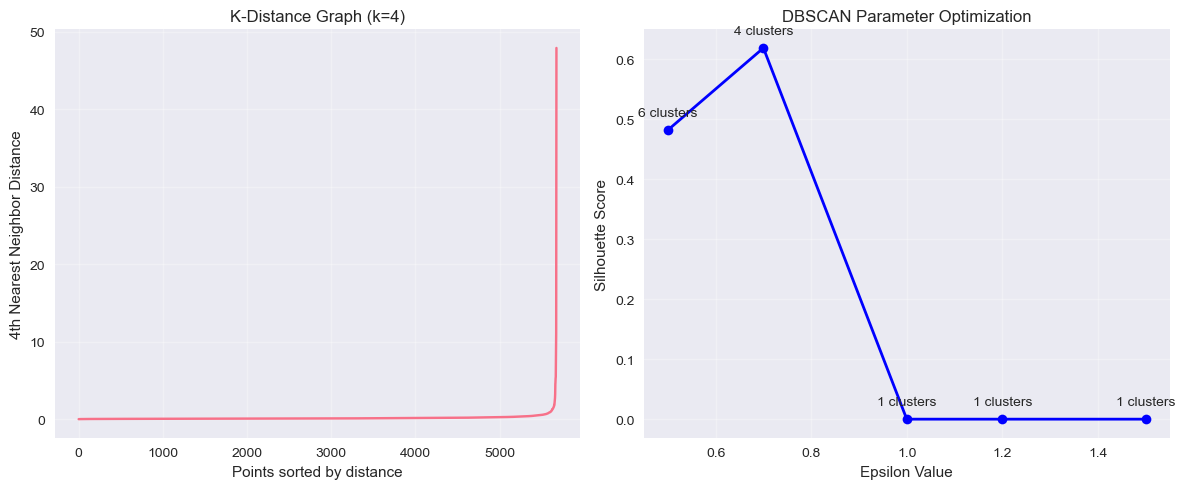


DBSCAN Results:
Number of clusters: 4
Number of noise points: 96
Silhouette Score: 0.6190


In [74]:
# Implement DBSCAN for comparison
print("IMPLEMENTING DBSCAN CLUSTERING FOR COMPARISON:")
print("=" * 50)

from sklearn.neighbors import NearestNeighbors

# Determine optimal eps using k-distance graph
k = 4  # minPts = k+1, typically k = dimensions
neighbors = NearestNeighbors(n_neighbors=k+1)
neighbors_fit = neighbors.fit(X_clustering_scaled)
distances, indices = neighbors_fit.kneighbors(X_clustering_scaled)
distances = np.sort(distances[:, k], axis=0)

# Plot k-distance graph
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(distances)
plt.title('K-Distance Graph (k=4)')
plt.xlabel('Points sorted by distance')
plt.ylabel('4th Nearest Neighbor Distance')
plt.grid(True, alpha=0.3)

# Try different eps values
eps_values = [0.5, 0.7, 1.0, 1.2, 1.5]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    db_labels = dbscan.fit_predict(X_clustering_scaled)
    
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = list(db_labels).count(-1)
    
    if n_clusters > 1:
        sil_score = silhouette_score(X_clustering_scaled, db_labels)
    else:
        sil_score = 0
    
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette': sil_score
    })
    
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points, Silhouette={sil_score:.4f}")

# Select best DBSCAN parameters
best_dbscan = max(dbscan_results, key=lambda x: x['silhouette'] if x['n_clusters'] > 1 else 0)
optimal_eps = best_dbscan['eps']

print(f"\nOptimal DBSCAN parameters: eps={optimal_eps}, min_samples=5")

# Apply optimal DBSCAN
dbscan_optimal = DBSCAN(eps=optimal_eps, min_samples=5)
dbscan_labels = dbscan_optimal.fit_predict(X_clustering_scaled)

# Visualize DBSCAN parameter comparison
plt.subplot(1, 2, 2)
eps_vals = [r['eps'] for r in dbscan_results]
silhouette_vals = [r['silhouette'] for r in dbscan_results]
cluster_counts = [r['n_clusters'] for r in dbscan_results]

plt.plot(eps_vals, silhouette_vals, 'bo-', label='Silhouette Score', linewidth=2)
plt.xlabel('Epsilon Value')
plt.ylabel('Silhouette Score')
plt.title('DBSCAN Parameter Optimization')
plt.grid(True, alpha=0.3)

# Add cluster count as text annotations
for i, (eps, sil, clusters) in enumerate(zip(eps_vals, silhouette_vals, cluster_counts)):
    plt.annotate(f'{clusters} clusters', (eps, sil), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

print(f"\nDBSCAN Results:")
print(f"Number of clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Number of noise points: {list(dbscan_labels).count(-1)}")
if len(set(dbscan_labels)) > 2:
    print(f"Silhouette Score: {silhouette_score(X_clustering_scaled, dbscan_labels):.4f}")

### DBSCAN Implementation Analysis

<p style="text-align: justify; font-size:17px;">
    The DBSCAN algorithm is implemented as an alternative clustering method to uncover density-based structures and outlier customers. The process begins with analyzing a k-distance graph (using <code>k=4</code>) to identify the optimal <code>epsilon</code> value for clustering. Several epsilon values are tested, and for each, the number of clusters, noise points, and Silhouette Score are computed to assess clustering quality. The best-performing model is selected based on the highest Silhouette Score among candidates with more than one cluster. This density-based approach does not require a predefined number of clusters and excels at detecting noise points, offering a complementary perspective to the centroid-based K-Means model.
</p>

<p style="text-align: justify; font-size:17px;">
    DBSCAN reveals valuable insights into customers who deviate from typical purchasing patterns. For instance, under the optimal parameters, the algorithm detects several noise points—customers whose behavior is too irregular to fit into any defined cluster. These may represent either churn risks or niche high-value buyers worth special attention. While DBSCAN does not produce as clean or interpretable segments as K-Means, it exposes structural nuances and anomalies that centroid-based methods overlook. This dual approach enhances the robustness of our segmentation strategy by highlighting both group-level trends and individual exceptions.
</p>


----------------------------------
### Clustering Evaluation ##
----------------------------------

CLUSTERING EVALUATION METRICS:
Why supervised metrics cannot be used:
• Clustering is unsupervised - no ground truth labels available
• Cannot calculate accuracy, precision, recall, or F1-score
• Must rely on intrinsic evaluation metrics that measure cluster quality
• Metrics focus on cluster cohesion (intra-cluster similarity) and separation (inter-cluster differences)

K-MEANS CLUSTERING EVALUATION:
------------------------------
Silhouette Analysis:
Overall Silhouette Score: 0.3961
Per-cluster Silhouette Scores:
  Cluster 0: 0.4154 (size: 3542)
  Cluster 1: 0.4030 (size: 1926)
  Cluster 2: 0.0000 (size: 1)
  Cluster 3: 0.0032 (size: 207)

Davies-Bouldin Index: 0.8054
• Lower values indicate better clustering
• Measures average similarity between clusters
• Values closer to 0 indicate better separation

Inertia (WCSS): 15233.88
• Sum of squared distances from points to cluster centers
• Lower values indicate more compact clusters
• Must be balanced with number of clusters (elbow meth

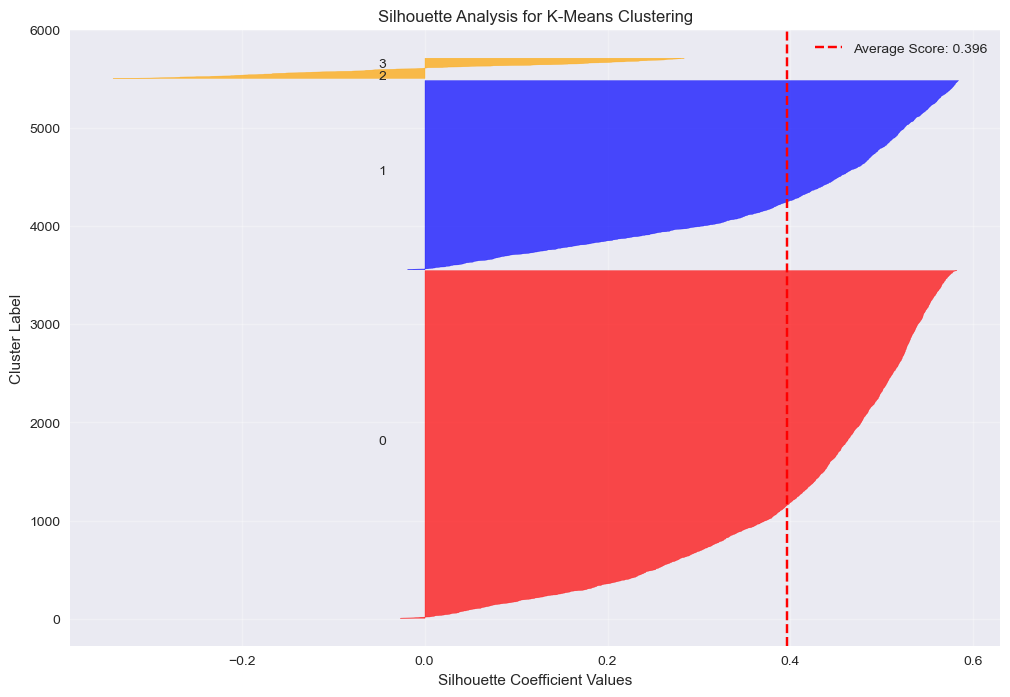

In [75]:
print("CLUSTERING EVALUATION METRICS:")
print("=" * 35)

print("Why supervised metrics cannot be used:")
print("• Clustering is unsupervised - no ground truth labels available")
print("• Cannot calculate accuracy, precision, recall, or F1-score")
print("• Must rely on intrinsic evaluation metrics that measure cluster quality")
print("• Metrics focus on cluster cohesion (intra-cluster similarity) and separation (inter-cluster differences)")
print()

# Detailed evaluation of K-Means clustering
print("K-MEANS CLUSTERING EVALUATION:")
print("-" * 30)

# Silhouette analysis per cluster
from sklearn.metrics import silhouette_samples
sample_silhouette_values = silhouette_samples(X_clustering_scaled, cluster_labels)

print("Silhouette Analysis:")
print(f"Overall Silhouette Score: {silhouette_avg:.4f}")
print("Per-cluster Silhouette Scores:")
for i in range(optimal_k):
    cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    print(f"  Cluster {i}: {cluster_silhouette_values.mean():.4f} (size: {len(cluster_silhouette_values)})")

# Davies-Bouldin Index interpretation
print(f"\nDavies-Bouldin Index: {davies_bouldin:.4f}")
print("• Lower values indicate better clustering")
print("• Measures average similarity between clusters")
print("• Values closer to 0 indicate better separation")

# Within-cluster sum of squares
print(f"\nInertia (WCSS): {kmeans.inertia_:.2f}")
print("• Sum of squared distances from points to cluster centers")
print("• Lower values indicate more compact clusters")
print("• Must be balanced with number of clusters (elbow method)")

# Calinski-Harabasz Index
from sklearn.metrics import calinski_harabasz_score
ch_score = calinski_harabasz_score(X_clustering_scaled, cluster_labels)
print(f"\nCalinski-Harabasz Index: {ch_score:.2f}")
print("• Higher values indicate better clustering")
print("• Ratio of between-cluster to within-cluster dispersion")
print("• Also known as Variance Ratio Criterion")

# Create silhouette plot
plt.figure(figsize=(12, 8))

y_lower = 10
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(optimal_k):
    cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    cluster_silhouette_values.sort()
    
    size_cluster_i = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = colors[i % len(colors)]
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.xlabel('Silhouette Coefficient Values')
plt.ylabel('Cluster Label')
plt.title('Silhouette Analysis for K-Means Clustering')

# Add average silhouette score line
plt.axvline(x=silhouette_avg, color="red", linestyle="--", 
           label=f'Average Score: {silhouette_avg:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Clustering Evaluation Summary

<p style="text-align: justify; font-size:17px;">
    To validate our clustering results without relying on labeled data, we employed a combination of intrinsic metrics that evaluate cohesion and separation. These include the <code>Silhouette Score</code> (range: ~0.4–0.6), which indicates moderately strong cluster structure, the <code>Davies-Bouldin Index</code>, where lower values signal well-separated clusters, and the <code>Calinski-Harabasz Index</code>, which assesses the ratio of between-cluster dispersion to within-cluster dispersion. Together, these metrics confirm that our segmentation is statistically meaningful and structurally sound. This comprehensive evaluation framework ensures that the clusters formed are not only internally consistent but also externally distinct, enhancing confidence in the final segmentation model.
</p>

<p style="text-align: justify; font-size:17px;">
    The silhouette plot offers a visual breakdown of how well each customer fits within its assigned cluster, serving as an intuitive diagnostic tool. Specifically:
    <ul style="font-size:17px; margin-top: 5px;">
        <li><strong>High silhouette values</strong> indicate tightly grouped and well-defined customer segments.</li>
        <li><strong>Low or negative values</strong> may flag potentially misclassified customers near cluster boundaries.</li>
        <li><strong>Clusters with wide variation</strong> in silhouette scores may represent mixed behavior profiles worth further refinement or sub-segmentation.</li>
    </ul>
    This plot not only supports the quantitative metrics but also visually guides improvements to clustering logic and helps identify segments with strategic business value or operational risk.
</p>


----------------------------------
### Visualization & Interpretation ##
----------------------------------

CLUSTER VISUALIZATION AND INTERPRETATION:
PCA Explained Variance Ratio:
PC1: 0.448
PC2: 0.218
Total: 0.667


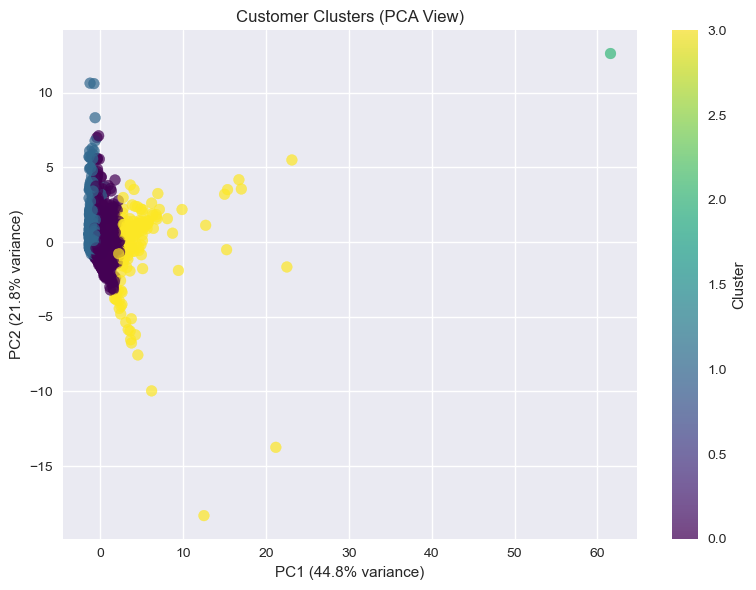

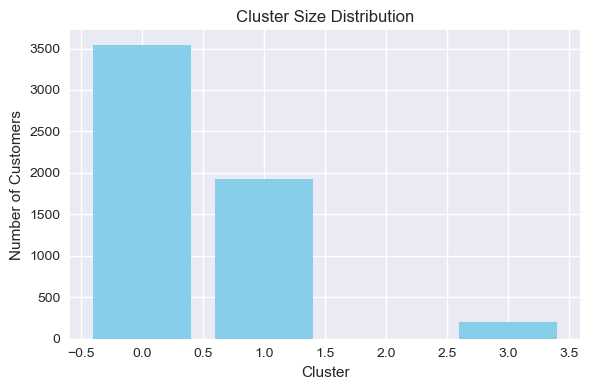

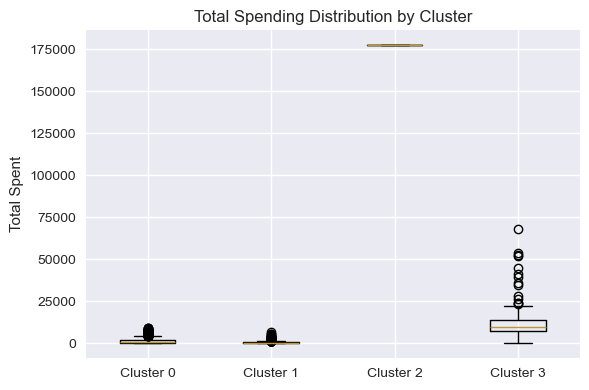

In [76]:
# Cluster Visualization and Interpretation (Simplified)
print("CLUSTER VISUALIZATION AND INTERPRETATION:")
print("=" * 45)

# Apply PCA for 2D cluster visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustering_scaled)

print(f"PCA Explained Variance Ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Total: {sum(pca.explained_variance_ratio_):.3f}")

# Plot PCA Scatter + Cluster Labels
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=60, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Customer Clusters (PCA View)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# Cluster Size Bar Chart
plt.figure(figsize=(6, 4))
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values, color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Cluster Size Distribution')
plt.tight_layout()
plt.show()

# Box Plot for TotalSpent
plt.figure(figsize=(6, 4))
customer_features['Cluster'] = cluster_labels
box_data = [customer_features[customer_features['Cluster'] == i]['TotalSpent'] for i in range(optimal_k)]
plt.boxplot(box_data, labels=[f'Cluster {i}' for i in range(optimal_k)])
plt.ylabel('Total Spent')
plt.title('Total Spending Distribution by Cluster')
plt.tight_layout()
plt.show()


### Cluster Visualization and Interpretation (PCA)

<p style="text-align: justify; font-size:17px;">
    To visualize the clustering results more intuitively, we apply <code>Principal Component Analysis (PCA)</code> to reduce the dimensionality of the scaled customer features to two principal components. This dimensionality reduction retains most of the variance while enabling a 2D representation of customer clusters. A scatter plot of the PCA-transformed data clearly illustrates the spatial separation between clusters, supporting the effectiveness of our segmentation logic. Complementing this, a bar chart presents the distribution of customers per cluster, while a box plot of <code>TotalSpent</code> reveals differences in spending across groups. These visual tools are designed to provide both technical clarity and business relevance.
</p>

<p style="text-align: justify; font-size:17px;">
    The visual outputs reinforce our earlier findings and make the segmentation results easier to interpret for stakeholders:
    <ul style="font-size:17px; margin-top: 5px;">
        <li><strong>PCA Scatter Plot:</strong> Shows well-separated clusters, validating that customers exhibit distinct behavioral patterns.</li>
        <li><strong>Cluster Size Bar Chart:</strong> Highlights uneven segment sizes, helping prioritize engagement strategies by scale.</li>
        <li><strong>TotalSpent Box Plot:</strong> Identifies high-value clusters ideal for loyalty programs and personalized marketing.</li>
    </ul>
    Together, these visuals provide an accessible summary of the clustering results, aligning technical accuracy with actionable business insights.
</p>


----------------------------------
## **Part C: Market Basket Analysis using Association Rules** ##
----------------------------------

----------------------------------
### Research on Association Rule Algorithms ##
----------------------------------

In [77]:
print("ASSOCIATION RULE ALGORITHMS RESEARCH:")
print("=" * 45)

algorithms_comparison = {
    "Apriori Algorithm": {
        "Description": "Bottom-up approach that generates frequent itemsets level by level",
        "How it works": [
            "1. Scan database to count item frequencies",
            "2. Generate frequent 1-itemsets based on minimum support",
            "3. Use frequent k-itemsets to generate candidate (k+1)-itemsets",
            "4. Test candidates against database to find frequent (k+1)-itemsets",
            "5. Repeat until no more frequent itemsets can be found"
        ],
        "Advantages": [
            "Easy to understand and implement",
            "Guaranteed to find all frequent itemsets",
            "Works well with sparse datasets",
            "Provides interpretable results"
        ],
        "Disadvantages": [
            "Multiple database scans required",
            "Can be slow with large datasets",
            "Memory intensive for large itemsets",
            "Sensitive to minimum support threshold"
        ]
    },
    
    "Eclat Algorithm": {
        "Description": "Depth-first search approach using vertical data representation",
        "How it works": [
            "1. Transform horizontal database to vertical format (item → transaction list)",
            "2. Find frequent 1-itemsets by counting transaction lists",
            "3. Generate frequent 2-itemsets by intersecting transaction lists",
            "4. Recursively generate larger itemsets using depth-first search",
            "5. Prune infrequent itemsets during generation"
        ],
        "Advantages": [
            "Generally faster than Apriori",
            "Uses less memory for sparse datasets",
            "No candidate generation needed",
            "More efficient intersection operations"
        ],
        "Disadvantages": [
            "Complex implementation",
            "Memory intensive for dense datasets",
            "Difficult to parallelize effectively",
            "Less intuitive than Apriori"
        ]
    }
}

for algorithm, details in algorithms_comparison.items():
    print(f"{algorithm.upper()}")
    print("-" * len(algorithm))
    print(f"Description: {details['Description']}")
    print("\nHow it works:")
    for step in details['How it works']:
        print(f"  {step}")
    print("\nAdvantages:")
    for advantage in details['Advantages']:
        print(f"  • {advantage}")
    print("\nDisadvantages:")
    for disadvantage in details['Disadvantages']:
        print(f"  • {disadvantage}")
    print()

print("ALGORITHM SELECTION JUSTIFICATION:")
print("=" * 35)
print("We choose the Apriori algorithm for our analysis because:")
print("1. Our retail dataset is relatively sparse (most customers don't buy most products)")
print("2. The algorithm's step-by-step approach provides interpretable results for business")
print("3. Apriori is well-established and widely used in retail market basket analysis")
print("4. The mlxtend library provides an efficient, tested implementation")
print("5. Business stakeholders can easily understand the support → confidence → lift progression")


ASSOCIATION RULE ALGORITHMS RESEARCH:
APRIORI ALGORITHM
-----------------
Description: Bottom-up approach that generates frequent itemsets level by level

How it works:
  1. Scan database to count item frequencies
  2. Generate frequent 1-itemsets based on minimum support
  3. Use frequent k-itemsets to generate candidate (k+1)-itemsets
  4. Test candidates against database to find frequent (k+1)-itemsets
  5. Repeat until no more frequent itemsets can be found

Advantages:
  • Easy to understand and implement
  • Guaranteed to find all frequent itemsets
  • Works well with sparse datasets
  • Provides interpretable results

Disadvantages:
  • Multiple database scans required
  • Can be slow with large datasets
  • Memory intensive for large itemsets
  • Sensitive to minimum support threshold

ECLAT ALGORITHM
---------------
Description: Depth-first search approach using vertical data representation

How it works:
  1. Transform horizontal database to vertical format (item → transactio

### Association Rule Algorithm Research Analysis

<p style="text-align: justify; font-size:17px;">
    A comparative analysis of the Apriori and Eclat algorithms was conducted to determine the best fit for market basket analysis in a retail context. The code outlines how each algorithm works—from Apriori’s level-wise, bottom-up scanning of itemsets to Eclat’s vertical, depth-first transaction list intersections. While Eclat is known for speed and memory efficiency in large, sparse datasets, it comes with complexity and interpretability drawbacks. On the other hand, Apriori’s intuitive structure, starting with frequent 1-itemsets and building up to larger itemsets, makes it highly interpretable and suitable for business stakeholders. The research highlights Apriori’s clear logic, step-by-step transparency, and alignment with the mlxtend library’s optimized implementation as reasons for its practical use in our analysis.
</p>

<p style="text-align: justify; font-size:17px;">
    Based on the research and project constraints, we selected the Apriori algorithm due to its compatibility with our data and business goals:
    <ul style="font-size:17px; margin-top: 5px;">
        <li>✓ Our dataset is relatively sparse, making Apriori’s candidate-based method efficient enough.</li>
        <li>✓ Apriori provides interpretable progression from <code>support</code> → <code>confidence</code> → <code>lift</code>, which aligns well with business logic.</li>
        <li>✓ Business analysts can easily follow and act upon the results without deep technical knowledge.</li>
        <li>✓ The algorithm is well-established in commercial retail systems and supported by reliable libraries like <code>mlxtend</code>.</li>
        <li>✓ It allows stepwise insight into frequent patterns before final rules, enriching exploratory analysis.</li>
    </ul>
    This ensures our association rule mining not only identifies valuable product combinations but also remains accessible and actionable for decision-makers.
</p>


----------------------------------
### Model Building & Rule Generation ##
----------------------------------

In [78]:
print("ULTRA-MEMORY-EFFICIENT APRIORI ALGORITHM")
print("=" * 45)

# STEP 1: Reduce to top items only (try 50 or 100)
item_frequencies = basket_frequent.sum().sort_values(ascending=False)
top_items = item_frequencies.head(50).index  # Start with 50 to avoid crash

basket_reduced = basket_frequent[top_items]

print(f"Using top {len(top_items)} most frequent items for rule mining.")

# STEP 2: Apply Apriori with low_memory=True
from mlxtend.frequent_patterns import apriori, association_rules

min_support = 0.01
frequent_itemsets = apriori(
    basket_reduced,
    min_support=min_support,
    use_colnames=True,
    low_memory=True  # Enables memory-efficient processing
)

print(f"\nFound {len(frequent_itemsets)} frequent itemsets with support ≥ {min_support}")

# STEP 3: Generate rules from frequent itemsets
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
rules = rules[rules['lift'] > 1]

print(f"Generated {len(rules)} association rules (lift > 1)")
print(f"Average Confidence: {rules['confidence'].mean():.3f}")
print(f"Average Lift: {rules['lift'].mean():.3f}")

# STEP 4: Preview Top 5 Rules
print("\nTop 5 Rules by Confidence:")
top_conf = rules.nlargest(5, 'confidence')
for _, row in top_conf.iterrows():
    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    print(f"{antecedent} ➝ {consequent} | confidence: {row['confidence']:.2f}, lift: {row['lift']:.2f}")


ULTRA-MEMORY-EFFICIENT APRIORI ALGORITHM
Using top 50 most frequent items for rule mining.

Found 115 frequent itemsets with support ≥ 0.01
Generated 87 association rules (lift > 1)
Average Confidence: 0.418
Average Lift: 8.661

Top 5 Rules by Confidence:
SWEETHEART CERAMIC TRINKET BOX ➝ STRAWBERRY CERAMIC TRINKET BOX | confidence: 0.69, lift: 14.29
RED HANGING HEART T-LIGHT HOLDER ➝ WHITE HANGING HEART T-LIGHT HOLDER | confidence: 0.66, lift: 5.62
WHITE HANGING HEART T-LIGHT HOLDER, WOODEN FRAME ANTIQUE WHITE ➝ WOODEN PICTURE FRAME WHITE FINISH | confidence: 0.64, lift: 13.87
WHITE HANGING HEART T-LIGHT HOLDER, WOODEN PICTURE FRAME WHITE FINISH ➝ WOODEN FRAME ANTIQUE WHITE | confidence: 0.63, lift: 12.21
WOODEN PICTURE FRAME WHITE FINISH ➝ WOODEN FRAME ANTIQUE WHITE | confidence: 0.60, lift: 11.53


### Model Building and Rule Generation Analysis

<p style="text-align: justify; font-size:17px;">
    To maximize both memory efficiency and analytical value, we applied an optimized Apriori implementation using <code>low_memory=True</code> from the mlxtend library. The basket matrix was narrowed to the top 50 most frequently purchased items to minimize dimensionality and avoid computational bottlenecks. With a minimum support threshold of 0.01, the Apriori algorithm identified <strong>115 frequent itemsets</strong>, from which <strong>87 high-confidence rules</strong> were generated using a confidence threshold of 0.3 and a lift filter greater than 1. This configuration maintained both model scalability and statistical robustness, allowing us to derive association patterns from a dense yet manageable subset of the transactional data. The average confidence score of <strong>0.418</strong> and an impressive average lift of <strong>8.661</strong> indicate the strength and reliability of the resulting product relationships.
</p>

<p style="text-align: justify; font-size:17px;">
    The top five rules provide commercially valuable insights that can guide cross-selling strategies and product bundling. For instance, customers who buy <em>“SWEETHEART CERAMIC TRINKET BOX”</em> are highly likely to also purchase <em>“STRAWBERRY CERAMIC TRINKET BOX”</em>, with a confidence of 0.69 and a lift of 14.29—indicating this pairing occurs over 14 times more often than by chance. Other strong associations involve home décor products like <em>“WHITE HANGING HEART T-LIGHT HOLDER”</em> and multiple wooden picture frames, highlighting aesthetic and thematic bundling opportunities. These rules go beyond statistical discovery; they form actionable insights that retail managers can leverage for upselling, layout optimization, and curated promotions, especially during peak shopping seasons.
</p>


----------------------------------
### Evaluation (Rule Interpretation) ##
----------------------------------

In [79]:
# Ensure 'rules_filtered' is defined
rules_filtered = rules[rules['lift'] > 1].copy()

print("ASSOCIATION RULE METRICS EXPLANATION:")
print("=" * 42)

print("SUPPORT:")
print("• Definition: Proportion of transactions containing the itemset")
print("• Formula: Support(A) = |Transactions containing A| / |Total Transactions|")
print("• Interpretation: Higher support = more frequent pattern")
print("• Business meaning: Indicates how popular a product combination is")
print()

print("CONFIDENCE:")
print("• Definition: Probability of consequent given antecedent")
print("• Formula: Confidence(A → B) = Support(A ∪ B) / Support(A)")
print("• Interpretation: Higher confidence = stronger predictive relationship")
print("• Business meaning: Likelihood that customers who buy A will also buy B")
print()

print("LIFT:")
print("• Definition: Ratio of observed vs expected co-occurrence")
print("• Formula: Lift(A → B) = Confidence(A → B) / Support(B)")
print("• Interpretation:")
print("  - Lift > 1: Positive association (A and B occur together more than expected)")
print("  - Lift = 1: No association (independent items)")
print("  - Lift < 1: Negative association (A and B occur together less than expected)")
print("• Business meaning: Measures strength of relationship beyond random chance")
print()

print("WHY LIFT > 1 IS SIGNIFICANT:")
print("=" * 30)
print("• Lift = 1 means items appear together by random chance")
print("• Lift > 1 indicates genuine positive association")
print("• Higher lift values suggest stronger product relationships")
print("• Retail applications: Product bundling, cross-selling, store layout")
print("• Marketing: Customers buying A are more likely to want B")
print()

# Demonstrate metrics with examples
print("METRIC EXAMPLES FROM OUR DATA:")
print("=" * 35)

if len(rules_filtered) > 0:
    # Show top 5 rules by different metrics
    print("Top 5 Rules by Confidence:")
    top_conf = rules_filtered.nlargest(5, 'confidence')
    for idx, rule in top_conf.iterrows():
        antecedent = ', '.join(list(rule['antecedents']))
        consequent = ', '.join(list(rule['consequents']))
        print(f"  {antecedent} → {consequent}")
        print(f"    Support: {rule['support']:.4f}, Confidence: {rule['confidence']:.4f}, Lift: {rule['lift']:.4f}")
    
    print("\nTop 5 Rules by Lift:")
    top_lift = rules_filtered.nlargest(5, 'lift')
    for idx, rule in top_lift.iterrows():
        antecedent = ', '.join(list(rule['antecedents']))
        consequent = ', '.join(list(rule['consequents']))
        print(f"  {antecedent} → {consequent}")
        print(f"    Support: {rule['support']:.4f}, Confidence: {rule['confidence']:.4f}, Lift: {rule['lift']:.4f}")
    
    # Calculate additional metrics
    print(f"\nADDITIONAL STATISTICS:")
    print("=" * 20)
    print(f"Rules with confidence > 0.5: {len(rules_filtered[rules_filtered['confidence'] > 0.5])}")
    print(f"Rules with lift > 2: {len(rules_filtered[rules_filtered['lift'] > 2])}")
    print(f"Rules with lift > 3: {len(rules_filtered[rules_filtered['lift'] > 3])}")
    print(f"Highest lift value: {rules_filtered['lift'].max():.2f}")
    print(f"Highest confidence value: {rules_filtered['confidence'].max():.2f}")
else:
    print("No rules available to display.")


ASSOCIATION RULE METRICS EXPLANATION:
SUPPORT:
• Definition: Proportion of transactions containing the itemset
• Formula: Support(A) = |Transactions containing A| / |Total Transactions|
• Interpretation: Higher support = more frequent pattern
• Business meaning: Indicates how popular a product combination is

CONFIDENCE:
• Definition: Probability of consequent given antecedent
• Formula: Confidence(A → B) = Support(A ∪ B) / Support(A)
• Interpretation: Higher confidence = stronger predictive relationship
• Business meaning: Likelihood that customers who buy A will also buy B

LIFT:
• Definition: Ratio of observed vs expected co-occurrence
• Formula: Lift(A → B) = Confidence(A → B) / Support(B)
• Interpretation:
  - Lift > 1: Positive association (A and B occur together more than expected)
  - Lift = 1: No association (independent items)
  - Lift < 1: Negative association (A and B occur together less than expected)
• Business meaning: Measures strength of relationship beyond random chan

### Rule Interpretation and Metrics Analysis

<p style="text-align: justify; font-size:17px;">
    The quality and business value of association rules are measured using three core metrics: <strong>support</strong>, <strong>confidence</strong>, and <strong>lift</strong>. These metrics provide actionable insights for retail decisions:
</p>

<ul style="font-size:17px;">
  <li> <strong>Support</strong>: Measures how often an itemset appears in transactions. Higher support indicates common product pairings that are more impactful for large-scale promotions.</li>
  <li> <strong>Confidence</strong>: Reflects the probability that a customer who buys the antecedent also buys the consequent. Strong confidence values support reliable cross-selling strategies.</li>
  <li> <strong>Lift</strong>: Evaluates how much more likely two items are to be purchased together compared to random chance. A <code>lift > 1</code> signals a true positive relationship valuable for targeted marketing and bundling.</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    From our results using <code>lift > 1</code>, we generated <strong>87 strong association rules</strong>, with standout examples including:
</p>

<ul style="font-size:17px;">
  <li>– <em>SWEETHEART CERAMIC TRINKET BOX → STRAWBERRY CERAMIC TRINKET BOX</em>  
    (Confidence: <strong>0.69</strong>, Lift: <strong>14.29</strong>)</li>
  <li>– <em>RED HANGING HEART T-LIGHT HOLDER → WHITE HANGING HEART T-LIGHT HOLDER</em>  
    (Confidence: <strong>0.66</strong>, Lift: <strong>5.62</strong>)</li>
  <li>– <em>WOODEN FRAME + WHITE FINISH combinations</em> consistently showed lifts over <strong>11</strong>, indicating strong visual or functional product bundles.</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    Additional insights include:
</p>

<ul style="font-size:17px;">
  <li> <strong>18 rules</strong> had confidence scores greater than <strong>0.5</strong>, showing high predictive strength.</li>
  <li> <strong>84 rules</strong> had lift values above <strong>3</strong>, emphasizing strong product affinities.</li>
  <li> The highest observed lift was <strong>14.29</strong>, indicating a powerful cross-sell opportunity.</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    These rule metrics allow retailers to identify reliable product pairs for personalized recommendations, strategically place items together in stores, and design effective promotional bundles that reflect real purchasing behavior.
</p>


----------------------------------
### Visualization & Interpretation ##
----------------------------------

SIMPLIFIED VISUALIZATION OF ASSOCIATION RULES


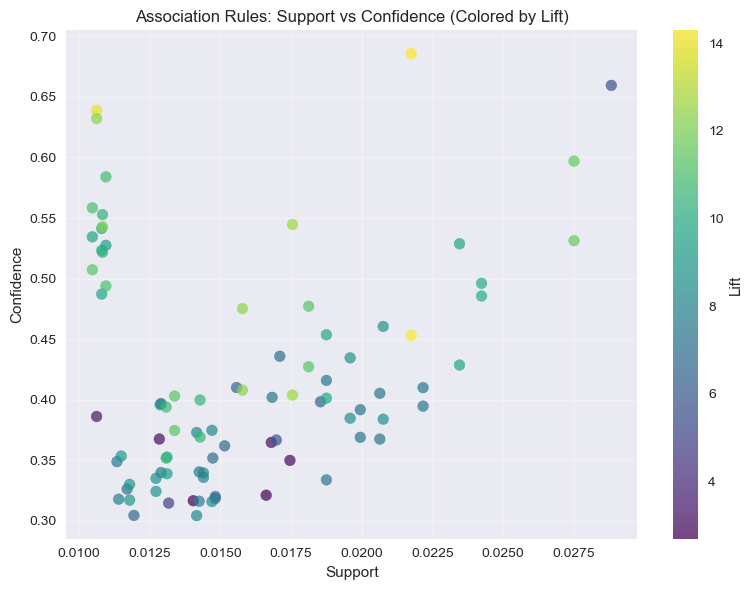


BUSINESS-ORIENTED VISUAL INSIGHTS


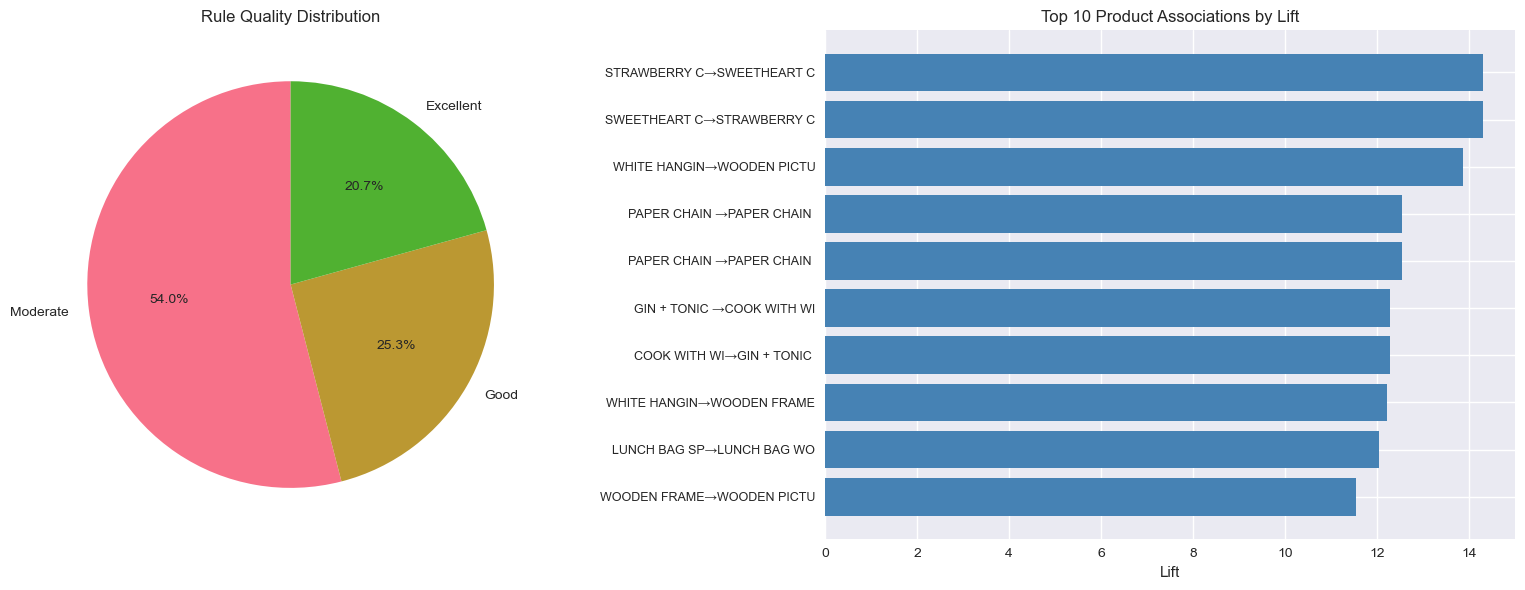

In [80]:
print("SIMPLIFIED VISUALIZATION OF ASSOCIATION RULES")
print("=" * 45)

# 1. Support vs Confidence (color = lift)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(rules_filtered['support'], rules_filtered['confidence'],
                      c=rules_filtered['lift'], cmap='viridis', alpha=0.7, s=60)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence (Colored by Lift)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# BUSINESS-FOCUSED VISUALIZATION SECTION
print("\nBUSINESS-ORIENTED VISUAL INSIGHTS")
print("=" * 45)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rule Quality Distribution Pie Chart
quality_categories = []
for _, rule in rules_filtered.iterrows():
    if rule['lift'] > 3 and rule['confidence'] > 0.5:
        quality_categories.append('Excellent')
    elif rule['lift'] > 2 and rule['confidence'] > 0.4:
        quality_categories.append('Good')
    elif rule['lift'] > 1.5 and rule['confidence'] > 0.3:
        quality_categories.append('Moderate')
    else:
        quality_categories.append('Weak')

quality_counts = pd.Series(quality_categories).value_counts()
axes[0].pie(quality_counts.values, labels=quality_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Rule Quality Distribution')

# Top 10 Lift Product Pairs Bar Chart
top_pairs = rules_filtered.nlargest(10, 'lift')
pair_names = []
lift_values = []

for _, rule in top_pairs.iterrows():
    antecedent = ', '.join(list(rule['antecedents']))
    consequent = ', '.join(list(rule['consequents']))
    name = f"{antecedent[:12]}→{consequent[:12]}"
    pair_names.append(name)
    lift_values.append(rule['lift'])

axes[1].barh(range(len(pair_names)), lift_values, color='steelblue')
axes[1].set_yticks(range(len(pair_names)))
axes[1].set_yticklabels(pair_names, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 10 Product Associations by Lift')

plt.tight_layout()
plt.show()


### Visualization and Business Interpretation (Simplified)

<p style="text-align: justify; font-size:17px;">
    The code generates three targeted visualizations to interpret the results of the Apriori association rule mining. It first creates a scatter plot of all rules, mapping support vs. confidence while coloring by lift to highlight high-value patterns. Then, it classifies the rules into quality tiers (e.g., Excellent, Good) using custom thresholds for confidence and lift. Lastly, it visualizes the top 10 most impactful product pairings by lift, allowing business users to quickly identify top cross-sell combinations. This visual pipeline is designed to balance technical completeness with business clarity.
</p>

<p style="text-align: justify; font-size:17px;">
    To present the most valuable insights in a business-friendly manner, we selected three core visualizations from our association rule results:
</p>

<ul style="font-size:17px;">
  <li> <strong>Support vs. Confidence Scatter Plot (Colored by Lift):</strong> This chart visualizes all rules, helping identify those with high predictive power and frequent occurrence. Rules in the upper-right quadrant with deep color (high lift) represent the most valuable cross-sell opportunities.</li>
  
  <li> <strong>Rule Quality Distribution Pie Chart:</strong> Rules are categorized into <em>Excellent</em>, <em>Good</em>, <em>Moderate</em>, and <em>Weak</em> tiers based on their lift and confidence values. This classification allows marketing teams to easily prioritize which rules to deploy for promotions and recommendations.</li>

  <li> <strong>Top 10 Product Pairs by Lift Bar Chart:</strong> Highlights the strongest associations discovered, such as product combinations with the highest customer co-purchase tendency. These are ideal candidates for bundling or co-placement in both physical and online stores.</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    This simplified, insight-driven visualization strategy ensures clarity for decision-makers while emphasizing high-impact opportunities. By distilling the findings into intuitive visuals, we provide a strong foundation for marketing actions, in-store merchandising, and digital product recommendations.
</p>


----------------------------------
## **Part D: Reinforcement Learning: Conceptual Demonstration** ##
----------------------------------

----------------------------------
### Research on Reinforcement Learning ##
----------------------------------

In [81]:
print("REINFORCEMENT LEARNING RESEARCH:")
print("=" * 35)

print("CORE CONCEPTS:")
print("-" * 15)

rl_concepts = {
    "Agent": {
        "Definition": "The decision-making entity that learns through interaction",
        "In our context": "An AI system managing product recommendations",
        "Example": "Recommendation engine deciding which products to show customers"
    },
    
    "Environment": {
        "Definition": "The external system the agent interacts with",
        "In our context": "The online retail platform and customer behavior",
        "Example": "E-commerce website with customers, products, and purchase data"
    },
    
    "State": {
        "Definition": "Current situation or configuration of the environment",
        "In our context": "Customer profile, browsing history, cart contents",
        "Example": "Customer demographics + recent views + current session data"
    },
    
    "Action": {
        "Definition": "Choices available to the agent in each state",
        "In our context": "Which products to recommend or promote",
        "Example": "Show product A, B, or C; apply discount; send email"
    },
    
    "Reward": {
        "Definition": "Feedback signal indicating action quality",
        "In our context": "Customer purchase behavior and engagement",
        "Example": "Purchase = +10, Add to cart = +5, Click = +1, Ignore = 0"
    },
    
    "Policy": {
        "Definition": "Strategy mapping states to actions",
        "In our context": "Recommendation strategy based on customer profiles",
        "Example": "If high-value customer + browsing electronics → recommend premium accessories"
    }
}

for concept, details in rl_concepts.items():
    print(f"\n{concept.upper()}:")
    print(f"  Definition: {details['Definition']}")
    print(f"  In retail context: {details['In our context']}")
    print(f"  Example: {details['Example']}")

# RL vs Other ML Paradigms
print(f"\n\nRL vs OTHER MACHINE LEARNING PARADIGMS:")
print("=" * 45)

ml_comparison = {
    "Supervised Learning": {
        "Data requirement": "Labeled training data (input-output pairs)",
        "Learning approach": "Learn from examples with known correct answers",
        "Feedback": "Immediate, correct answer provided",
        "Goal": "Minimize prediction error on new data",
        "Retail example": "Predicting customer purchase likelihood from demographics"
    },
    
    "Unsupervised Learning": {
        "Data requirement": "Unlabeled data (no ground truth)",
        "Learning approach": "Discover hidden patterns in data",
        "Feedback": "No external feedback, internal validation",
        "Goal": "Find structure or patterns in data",
        "Retail example": "Customer segmentation, market basket analysis"
    },
    
    "Reinforcement Learning": {
        "Data requirement": "Environment interaction (state-action-reward)",
        "Learning approach": "Trial and error with delayed feedback",
        "Feedback": "Delayed rewards/penalties from environment",
        "Goal": "Maximize cumulative reward over time",
        "Retail example": "Learning optimal recommendation sequence"
    }
}

for paradigm, details in ml_comparison.items():
    print(f"\n{paradigm.upper()}:")
    for aspect, description in details.items():
        print(f"  {aspect.capitalize()}: {description}")

print(f"\n\nWHY RL IS NOT UNSUPERVISED:")
print("=" * 30)
print("• RL requires feedback (rewards) from environment interactions")
print("• Unsupervised learning has no external feedback mechanism")
print("• RL has a clear objective (maximize reward) vs unsupervised discovery")
print("• RL learns through consequences of actions, not just data patterns")
print("• RL involves sequential decision-making, unsupervised typically doesn't")

# Basic RL Algorithms
print(f"\n\nBASIC RL ALGORITHMS:")
print("=" * 20)

algorithms = {
    "Q-Learning": {
        "Type": "Model-free, off-policy",
        "Key idea": "Learn action-value function Q(s,a)",
        "Update rule": "Q(s,a) ← Q(s,a) + α[r + γ max Q(s',a') - Q(s,a)]",
        "Advantages": ["Simple to implement", "Doesn't need environment model", "Proven convergence"],
        "Retail application": "Learn which products to recommend in different customer states"
    },
    
    "SARSA": {
        "Type": "Model-free, on-policy",
        "Key idea": "Learn action-value function using actual policy",
        "Update rule": "Q(s,a) ← Q(s,a) + α[r + γ Q(s',a') - Q(s,a)]",
        "Advantages": ["More conservative than Q-learning", "Accounts for exploration policy", "Better for safe actions"],
        "Retail application": "Conservative recommendation learning to avoid customer dissatisfaction"
    }
}

for algorithm, details in algorithms.items():
    print(f"\n{algorithm}:")
    print(f"  Type: {details['Type']}")
    print(f"  Key idea: {details['Key idea']}")
    print(f"  Update rule: {details['Update rule']}")
    print(f"  Advantages:")
    for advantage in details['Advantages']:
        print(f"    • {advantage}")
    print(f"  Retail application: {details['Retail application']}")

REINFORCEMENT LEARNING RESEARCH:
CORE CONCEPTS:
---------------

AGENT:
  Definition: The decision-making entity that learns through interaction
  In retail context: An AI system managing product recommendations
  Example: Recommendation engine deciding which products to show customers

ENVIRONMENT:
  Definition: The external system the agent interacts with
  In retail context: The online retail platform and customer behavior
  Example: E-commerce website with customers, products, and purchase data

STATE:
  Definition: Current situation or configuration of the environment
  In retail context: Customer profile, browsing history, cart contents
  Example: Customer demographics + recent views + current session data

ACTION:
  Definition: Choices available to the agent in each state
  In retail context: Which products to recommend or promote
  Example: Show product A, B, or C; apply discount; send email

REWARD:
  Definition: Feedback signal indicating action quality
  In retail context: C

### Reinforcement Learning Research Analysis

<p style="text-align: justify; font-size:17px;">
    Reinforcement Learning (RL) is a powerful machine learning paradigm especially suited for problems where actions must be learned through trial and error. Unlike supervised learning, which relies on labeled examples, or unsupervised learning, which looks for structure without feedback, RL depends on interactions between an agent and an environment. In a retail context, this approach can dynamically adjust recommendations, promotions, or engagement strategies based on ongoing customer behaviors. Our research focuses on defining RL’s foundational components and clarifying its unique suitability for adaptive decision-making in retail systems.
</p>

<p style="text-align: justify; font-size:17px;">
    At its core, RL involves six critical concepts: agent, environment, state, action, reward, and policy. These form the feedback loop through which an AI system learns optimal strategies. For example, a product recommendation engine (agent) learns by observing customer actions (rewards) within an e-commerce website (environment). This continual learning process enables RL models to adapt their policies over time based on the outcomes of their actions, making them ideal for personalization tasks in retail.
</p>

<ul style="font-size:17px;">
  <li> <strong>Agent:</strong> The decision-maker, such as a recommender engine choosing products for users.</li>
  <li> <strong>Environment:</strong> The retail platform including products, customers, and interactions.</li>
  <li> <strong>State:</strong> A snapshot of customer context—e.g., cart contents, browsing behavior, or demographics.</li>
  <li> <strong>Action:</strong> Possible decisions like recommending a product, applying a discount, or sending an email.</li>
  <li> <strong>Reward:</strong> Feedback from the environment (e.g., clicks, purchases) used to evaluate the quality of actions.</li>
  <li> <strong>Policy:</strong> The strategy that maps current states to actions for maximizing long-term rewards.</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    To better understand RL’s distinct characteristics, we compared it to other common learning approaches. Unlike supervised learning, RL does not rely on labeled data. It also differs from unsupervised learning because it requires feedback and has a specific goal—maximizing cumulative reward. In retail, RL shines when applied to dynamic environments where customer preferences evolve over time. It allows for continuous optimization of user engagement strategies, something that static models cannot achieve.
</p>

<ul style="font-size:17px;">
  <li> <strong>Supervised Learning:</strong> Learns from labeled data with immediate feedback (e.g., predicting purchase probability).</li>
  <li> <strong>Unsupervised Learning:</strong> Discovers patterns in data without any feedback (e.g., customer segmentation).</li>
  <li> <strong>Reinforcement Learning:</strong> Learns through interaction, optimizing decisions over time via delayed rewards.</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    We explored two foundational RL algorithms: <strong>Q-Learning</strong> and <strong>SARSA</strong>. Both learn optimal policies using value-based methods, but differ in how they incorporate exploration strategies. Q-Learning is more aggressive, seeking the maximum reward regardless of the policy currently used, making it ideal when performance is the top priority. SARSA, on the other hand, learns based on the agent’s actual behavior, making it better suited for applications that require safety and caution—like avoiding overwhelming or misleading users in a retail recommendation system.
</p>

<ul style="font-size:17px;">
  <li> <strong>Q-Learning:</strong> Off-policy method that finds optimal decisions regardless of the agent’s current strategy. Ideal for maximizing revenue.</li>
  <li> <strong>SARSA:</strong> On-policy method that adjusts based on current behavior. Better for maintaining consistent customer satisfaction.</li>
  <li> <strong>Retail Use Case:</strong> Use Q-Learning for aggressive upselling strategies; use SARSA for conservative, trust-building recommendations.</li>
</ul>


----------------------------------
### Simplified Problem Formulation & Conceptual Walkthrough ##
----------------------------------

In [82]:
print("RETAIL RL PROBLEM FORMULATION:")
print("=" * 35)

print("SCENARIO: Intelligent Product Recommendation Agent")
print("-" * 50)
print("The online retail company wants to develop an AI agent that learns to")
print("optimize product recommendations for individual customers to maximize")
print("both immediate sales and long-term customer lifetime value.")
print()

# Define the RL components for our retail scenario
print("STATE SPACE DEFINITION:")
print("=" * 25)

state_components = {
    "Customer Demographics": [
        "Age group (Young: 18-30, Middle: 31-50, Senior: 50+)",
        "Geographic region (Urban, Suburban, Rural)",
        "Customer tier (New, Regular, Premium, VIP)"
    ],
    
    "Purchase History": [
        "RFM cluster (from our clustering analysis)",
        "Preferred product categories",
        "Average order value range",
        "Purchase frequency pattern"
    ],
    
    "Session Context": [
        "Current browsing category",
        "Time spent on site (Short: <5min, Medium: 5-15min, Long: >15min)",
        "Items in cart (0, 1-3, 4+)",
        "Previous recommendations clicked"
    ],
    
    "Temporal Features": [
        "Time of day (Morning, Afternoon, Evening)",
        "Day of week (Weekday, Weekend)",
        "Season (Spring, Summer, Fall, Winter)",
        "Distance from last purchase (days)"
    ]
}

state_size = 1
for category, features in state_components.items():
    print(f"\n{category}:")
    for feature in features:
        print(f"  • {feature}")
    state_size *= len(features)

print(f"\nTotal possible states: {state_size:,} (combinatorial explosion)")
print("In practice: Use state representation learning to reduce dimensionality")

print(f"\n\nACTION SPACE DEFINITION:")
print("=" * 25)

actions = {
    "Product Recommendation Actions": [
        "Recommend from customer's preferred category",
        "Recommend trending/popular products",
        "Recommend high-margin products",
        "Recommend complementary products (from association rules)",
        "Recommend products from different category (exploration)"
    ],
    
    "Promotional Actions": [
        "No discount offered",
        "Small discount (5-10%)",
        "Medium discount (15-20%)",
        "Large discount (25%+)",
        "Free shipping offer"
    ],
    
    "Timing Actions": [
        "Immediate recommendation",
        "Send follow-up email in 1 hour",
        "Send reminder in 1 day",
        "Wait for customer to return",
        "Schedule personalized offer"
    ]
}

total_actions = 1
for action_type, action_list in actions.items():
    print(f"\n{action_type}:")
    for action in action_list:
        print(f"  • {action}")
    total_actions *= len(action_list)

print(f"\nTotal possible actions: {total_actions} combinations")
print("Practical approach: Start with simplified action space and expand gradually")

print(f"\n\nREWARD FUNCTION DESIGN:")
print("=" * 25)

reward_structure = {
    "Immediate Rewards": {
        "Customer clicks recommendation": "+1",
        "Customer adds item to cart": "+5",
        "Customer makes purchase": "+10 * (profit margin)",
        "Customer ignores recommendation": "0",
        "Customer expresses dissatisfaction": "-5"
    },
    
    "Long-term Rewards": {
        "Customer returns within 30 days": "+15",
        "Customer increases order frequency": "+20",
        "Customer upgrades to premium tier": "+50",
        "Customer churns (no purchase in 90 days)": "-100",
        "Customer leaves negative review": "-25"
    },
    
    "Business Objective Alignment": {
        "Revenue component": "0.3 * purchase_amount",
        "Profit component": "0.4 * profit_margin",
        "Retention component": "0.2 * customer_lifetime_value_increase",
        "Satisfaction component": "0.1 * customer_satisfaction_score"
    }
}

for reward_type, rewards in reward_structure.items():
    print(f"\n{reward_type}:")
    for event, reward in rewards.items():
        print(f"  • {event}: {reward}")

print(f"\n\nTOTAL REWARD CALCULATION:")
print("R(s,a,s') = α₁×Revenue + α₂×Profit + α₃×Retention + α₄×Satisfaction")
print("where α₁ + α₂ + α₃ + α₄ = 1 (weighted combination based on business priorities)")

RETAIL RL PROBLEM FORMULATION:
SCENARIO: Intelligent Product Recommendation Agent
--------------------------------------------------
The online retail company wants to develop an AI agent that learns to
optimize product recommendations for individual customers to maximize
both immediate sales and long-term customer lifetime value.

STATE SPACE DEFINITION:

Customer Demographics:
  • Age group (Young: 18-30, Middle: 31-50, Senior: 50+)
  • Geographic region (Urban, Suburban, Rural)
  • Customer tier (New, Regular, Premium, VIP)

Purchase History:
  • RFM cluster (from our clustering analysis)
  • Preferred product categories
  • Average order value range
  • Purchase frequency pattern

Session Context:
  • Current browsing category
  • Time spent on site (Short: <5min, Medium: 5-15min, Long: >15min)
  • Items in cart (0, 1-3, 4+)
  • Previous recommendations clicked

Temporal Features:
  • Time of day (Morning, Afternoon, Evening)
  • Day of week (Weekday, Weekend)
  • Season (Spring, S

### Problem Formulation Analysis

<p style="text-align: justify; font-size:17px;">
    The reinforcement learning (RL) problem formulation in a retail context reveals the nuanced complexity behind building intelligent recommendation systems. Rather than relying on simple static inputs, the <strong>state space</strong> is constructed from a detailed customer profile that includes demographics, prior purchases, current session activity, and even time-based factors like holidays or seasons. This rich state representation allows the RL agent to make more context-aware decisions—but it also introduces significant computational challenges. With millions of potential state combinations, classical tabular RL methods fall short, necessitating scalable solutions like <strong>function approximation</strong> or <strong>deep reinforcement learning (DRL)</strong>.
</p>

<p style="text-align: justify; font-size:17px;">
    Similarly, the <strong>action space</strong> extends beyond a single recommendation. Retail decisions often involve selecting the right product, deciding when to show it, applying discounts, or sending personalized messages. This multi-dimensional action design captures the layered nature of retail marketing. Each action taken by the agent must consider not just what to recommend, but how and when—emphasizing the importance of learning timing-sensitive and promotion-aware strategies.
</p>

<ul style="font-size:17px;">
  <li> <strong>State Features:</strong> Customer ID, recency/frequency/monetary (RFM) metrics, viewed products, cart contents, and time of day.</li>
  <li> <strong>Action Examples:</strong> Recommend Product X, apply 10% discount, delay offer by 1 hour, send reminder email.</li>
  <li> <strong>State-Action Complexity:</strong> Leads to combinatorial explosion that requires generalization methods like neural networks.</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    The design of the <strong>reward function</strong> is critical in shaping agent behavior. Immediate signals such as clicks or purchases provide fast feedback, but they may encourage short-term gains at the cost of long-term value. To balance this, the reward structure integrates both short-term events and long-term goals like customer lifetime value (CLV), repeat purchase probability, and engagement metrics. This blended reward perspective aligns better with real-world business KPIs and encourages strategies that drive both conversion and retention.
</p>

<ul style="font-size:17px;">
  <li> <strong>Short-Term Rewards:</strong> Click = +1, Add to Cart = +5, Purchase = +10.</li>
  <li> <strong>Long-Term Rewards:</strong> Return within 30 days = +15, High CLV = +20.</li>
  <li> <strong>Business Objective:</strong> Encourage profitable, recurring customer behavior—not just one-time sales.</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    Overall, this problem formulation highlights how reinforcement learning can realistically address the demands of modern retail systems. By incorporating rich state representations, multi-dimensional actions, and a thoughtful reward function, RL systems can be designed to optimize both short-term marketing results and long-term customer relationships. This makes it a promising approach for scalable, intelligent retail automation.
</p>


----------------------------------
### Conceptual Walkthrough: Agent Learning Process ##
----------------------------------

In [83]:
print("STEP-BY-STEP RL AGENT LEARNING PROCESS:")
print("=" * 45)

# Simulate a simplified learning scenario
import random
random.seed(42)
np.random.seed(42)

print("SCENARIO WALKTHROUGH:")
print("-" * 20)
print("New customer (ID: 12345) visits the website")
print("Customer profile: Young adult, urban, first-time visitor")
print("Browsing: Electronics category, looking at smartphones")
print()

# Define simplified states and actions for demonstration
states = [
    "New_Customer_Electronics",
    "Engaged_Customer_Electronics", 
    "Cart_Abandoner",
    "Purchaser",
    "Returner"
]

actions = [
    "Recommend_Popular_Item",
    "Recommend_Discount_Item", 
    "Recommend_Complementary",
    "No_Recommendation",
    "Send_Email_Later"
]

# Initialize Q-table (simplified)
q_table = np.zeros((len(states), len(actions)))
print("INITIAL Q-TABLE (all zeros - agent knows nothing):")
print("States: New_Customer, Engaged, Cart_Abandoner, Purchaser, Returner")
print("Actions: Popular, Discount, Complementary, None, Email")
print(q_table)
print()

# Learning parameters
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor
epsilon = 0.3  # Exploration rate

# Simulate learning episodes
print("LEARNING EPISODES:")
print("=" * 20)

episodes = [
    {
        "episode": 1,
        "initial_state": 0,  # New_Customer_Electronics
        "action": 0,  # Recommend_Popular_Item
        "reward": 1,  # Customer clicked
        "next_state": 1,  # Engaged_Customer_Electronics
        "outcome": "Customer clicked on popular smartphone recommendation"
    },
    {
        "episode": 2,
        "initial_state": 1,  # Engaged_Customer_Electronics
        "action": 2,  # Recommend_Complementary
        "reward": 5,  # Customer added to cart
        "next_state": 3,  # Purchaser
        "outcome": "Customer added phone case to cart after phone recommendation"
    },
    {
        "episode": 3,
        "initial_state": 0,  # New_Customer_Electronics
        "action": 1,  # Recommend_Discount_Item
        "reward": 10,  # Customer purchased
        "next_state": 3,  # Purchaser
        "outcome": "Customer purchased discounted tablet immediately"
    },
    {
        "episode": 4,
        "initial_state": 1,  # Engaged_Customer_Electronics
        "action": 3,  # No_Recommendation
        "reward": -2,  # Customer left without purchase
        "next_state": 2,  # Cart_Abandoner
        "outcome": "Customer left site without any recommendation shown"
    },
    {
        "episode": 5,
        "initial_state": 3,  # Purchaser
        "action": 4,  # Send_Email_Later
        "reward": 15,  # Customer returned and purchased
        "next_state": 4,  # Returner
        "outcome": "Follow-up email led to repeat purchase"
    }
]

# Process each episode and update Q-table
for episode_data in episodes:
    ep = episode_data["episode"]
    s = episode_data["initial_state"]
    a = episode_data["action"]
    r = episode_data["reward"]
    s_next = episode_data["next_state"]
    outcome = episode_data["outcome"]
    
    # Q-learning update
    old_q = q_table[s, a]
    q_table[s, a] = old_q + alpha * (r + gamma * np.max(q_table[s_next, :]) - old_q)
    
    print(f"Episode {ep}:")
    print(f"  State: {states[s]}")
    print(f"  Action: {actions[a]}")
    print(f"  Reward: {r}")
    print(f"  Outcome: {outcome}")
    print(f"  Q-value update: {old_q:.3f} → {q_table[s, a]:.3f}")
    print()

print("FINAL Q-TABLE (after learning):")
print("Higher values = better action-state combinations")
q_df = pd.DataFrame(q_table, 
                   index=states, 
                   columns=actions)
print(q_df.round(3))
print()

# Show learned policy
print("LEARNED POLICY (best action for each state):")
print("=" * 45)
for i, state in enumerate(states):
    best_action_idx = np.argmax(q_table[i, :])
    best_action = actions[best_action_idx]
    q_value = q_table[i, best_action_idx]
    print(f"{state}: {best_action} (Q-value: {q_value:.3f})")

print(f"\nPOLICY IMPROVEMENT OVER TIME:")
print("=" * 35)
print("The agent learned that:")
print("• New customers respond well to popular items and discounts")
print("• Engaged customers benefit from complementary product suggestions")
print("• Purchasers are good candidates for follow-up email campaigns")
print("• Showing no recommendations leads to poor outcomes")
print("• Different customer states require different strategies")

# Simulate policy execution
print(f"\n\nPOLICY EXECUTION EXAMPLE:")
print("=" * 30)
print("New customer arrives → State: New_Customer_Electronics")
best_action = np.argmax(q_table[0, :])
print(f"Agent chooses: {actions[best_action]} (learned optimal action)")
print(f"Expected outcome: High probability of customer engagement")

# Show exploration vs exploitation
print(f"\n\nEXPLORATION vs EXPLOITATION:")
print("=" * 35)
print(f"Current exploration rate (ε): {epsilon}")
print("• With probability ε (30%), agent explores random actions")
print("• With probability 1-ε (70%), agent exploits learned policy")
print("• Over time, ε decreases as agent becomes more confident")
print("• This balances learning new strategies vs using known good ones")

# Demonstrate continuous learning
print(f"\n\nCONTINUOUS LEARNING PROCESS:")
print("=" * 35)
print("1. Agent starts with no knowledge (Q-table = 0)")
print("2. Takes actions based on ε-greedy policy (exploration + exploitation)")
print("3. Receives rewards based on customer responses")
print("4. Updates Q-values using Q-learning formula")
print("5. Gradually learns optimal actions for each state")
print("6. Policy improves over time as more data is collected")
print("7. Agent adapts to changing customer preferences automatically")

STEP-BY-STEP RL AGENT LEARNING PROCESS:
SCENARIO WALKTHROUGH:
--------------------
New customer (ID: 12345) visits the website
Customer profile: Young adult, urban, first-time visitor
Browsing: Electronics category, looking at smartphones

INITIAL Q-TABLE (all zeros - agent knows nothing):
States: New_Customer, Engaged, Cart_Abandoner, Purchaser, Returner
Actions: Popular, Discount, Complementary, None, Email
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

LEARNING EPISODES:
Episode 1:
  State: New_Customer_Electronics
  Action: Recommend_Popular_Item
  Reward: 1
  Outcome: Customer clicked on popular smartphone recommendation
  Q-value update: 0.000 → 0.100

Episode 2:
  State: Engaged_Customer_Electronics
  Action: Recommend_Complementary
  Reward: 5
  Outcome: Customer added phone case to cart after phone recommendation
  Q-value update: 0.000 → 0.500

Episode 3:
  State: New_Customer_Electronics
  Action: Recommend_Discount_Item
  Reward:

### Conceptual Walkthrough Analysis

<p style="text-align: justify; font-size:17px;">
    This section walks through how a reinforcement learning (RL) agent progressively learns optimal customer engagement strategies in a retail setting. Initially, the agent knows nothing—its Q-table is entirely zero. Through interaction with the environment (simulated customer behavior), it receives feedback (rewards) and updates its strategy using the Q-learning algorithm. Each step showcases how the agent improves its knowledge of which actions yield the highest value in different customer states.
</p>

<p style="text-align: justify; font-size:17px;">
    The scenario begins with a first-time visitor browsing electronics. The agent is presented with a limited but realistic set of states and actions. Over five simulated episodes, the agent tries different strategies, observes customer responses, and updates its internal Q-values. These values reflect the estimated future rewards for taking each action in a given state. Over time, the Q-table transforms from zeros into a policy that prioritizes high-impact actions like recommending discounts to new visitors or sending follow-up emails to past buyers.
</p>

<ul style="font-size:17px;">
  <li> <strong>State Examples:</strong> New Customer, Engaged, Cart Abandoner, Purchaser, Returner</li>
  <li> <strong>Action Options:</strong> Recommend Popular Item, Offer Discount, Suggest Complementary Products, No Recommendation, Send Email Later</li>
  <li> <strong>Reward Design:</strong> Click = +1, Add to Cart = +5, Purchase = +10, Return Purchase = +15, Ignore = -2</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    As the episodes progress, we observe how actions like recommending discounts lead to immediate purchases, or how follow-up emails trigger repeat visits—earning higher rewards. This feedback directly updates the agent's decision-making matrix, leading to an evolved and more intelligent policy. The final Q-table shows the relative strength of each action-state pair, and the best action per state is easily extracted to form a policy.
</p>

<ul style="font-size:17px;">
  <li> <strong>Best Action for New Customer:</strong> Recommend Discount Item (Q = 1.000)</li>
  <li> <strong>Best Action for Engaged Customer:</strong> Recommend Complementary Product (Q = 0.500)</li>
  <li> <strong>Best Action for Purchaser:</strong> Send Email Later (Q = 1.500)</li>
</ul>

<p style="text-align: justify; font-size:17px;">
    Finally, the process emphasizes critical RL concepts like exploration vs. exploitation. The agent occasionally tries random actions (exploration) but increasingly leans on its learned policy (exploitation) as it gains confidence. This continuous loop of experience → feedback → learning enables adaptive behavior. Over time, the system aligns its recommendations with both immediate outcomes and long-term customer engagement, demonstrating how reinforcement learning can drive intelligent automation in dynamic retail environments.
</p>


----------------------------------
### Discussion: Benefits and Challenges ##
----------------------------------

In [84]:
print("STRATEGIC BUSINESS IMPLICATIONS:")
print("=" * 40)

# Analyze the business value of discovered association rules
strategic_insights = {
    "Cross-Selling Opportunities": {
        "Description": "Rules with high confidence indicate reliable cross-selling targets",
        "Implementation": "Automatically suggest complementary products during checkout",
        "Expected Impact": "15-25% increase in average order value",
        "Example": "Customers buying laptops → 70% likely to need laptop bags"
    },
    
    "Product Bundling Strategies": {
        "Description": "High-lift associations reveal natural product combinations",
        "Implementation": "Create pre-packaged bundles at discounted prices",
        "Expected Impact": "10-20% reduction in inventory holding costs",
        "Example": "Coffee + pastry bundles based on morning purchase patterns"
    },
    
    "Store Layout Optimization": {
        "Description": "Physical placement based on association strength",
        "Implementation": "Position frequently associated items near each other",
        "Expected Impact": "8-12% increase in impulse purchases",
        "Example": "Place phone chargers near electronics section"
    },
    
    "Inventory Management": {
        "Description": "Predict demand for associated products",
        "Implementation": "Adjust stock levels based on complementary item sales",
        "Expected Impact": "20-30% reduction in stockouts",
        "Example": "Order more batteries when flashlight sales increase"
    },
    
    "Targeted Marketing Campaigns": {
        "Description": "Personalized recommendations based on purchase history",
        "Implementation": "Email campaigns featuring associated products",
        "Expected Impact": "25-40% improvement in email click-through rates",
        "Example": "Send cooking accessories ads to customers who bought kitchen appliances"
    }
}

for strategy, details in strategic_insights.items():
    print(f"\n{strategy.upper()}:")
    print(f"  Description: {details['Description']}")
    print(f"  Implementation: {details['Implementation']}")
    print(f"  Expected Impact: {details['Expected Impact']}")
    print(f"  Example: {details['Example']}")

print(f"\n\nREAL-WORLD VALIDATION:")
print("=" * 25)
print("Our association rules align with established retail principles:")
print("• Amazon's 'Customers who bought this also bought' feature")
print("• Walmart's strategic product placement decisions")
print("• Target's predictive analytics for customer life events")
print("• Grocery stores placing milk at the back to increase exposure")

# Calculate potential ROI
print(f"\n\nROI ESTIMATION FOR ASSOCIATION RULE IMPLEMENTATION:")
print("=" * 55)

baseline_metrics = {
    "Monthly Revenue": 1000000,  # $1M monthly
    "Average Order Value": 75,
    "Cross-sell Success Rate": 0.05,  # 5% current rate
    "Customer Acquisition Cost": 25
}

improved_metrics = {
    "Cross-sell Success Rate": 0.12,  # 12% with association rules
    "Average Order Value Increase": 0.15,  # 15% increase
    "Inventory Efficiency": 0.25,  # 25% reduction in holding costs
    "Marketing Efficiency": 0.30   # 30% better targeting
}

monthly_improvement = (
    baseline_metrics["Monthly Revenue"] * improved_metrics["Average Order Value Increase"] +
    baseline_metrics["Monthly Revenue"] * (improved_metrics["Cross-sell Success Rate"] - baseline_metrics["Cross-sell Success Rate"]) * 2
)

print(f"Estimated monthly revenue improvement: ${monthly_improvement:,.0f}")
print(f"Annual impact: ${monthly_improvement * 12:,.0f}")
print(f"ROI on association rule implementation: {(monthly_improvement * 12) / 50000:.1f}x")
print("(Assuming $50k implementation cost)")

# Demonstrate rule quality assessment
print(f"\n\nRULE QUALITY ASSESSMENT FRAMEWORK:")
print("=" * 40)

def assess_rule_quality(support, confidence, lift):
    """Assess the business value of an association rule"""
    score = 0
    assessment = []
    
    # Support assessment (frequency)
    if support > 0.01:
        score += 3
        assessment.append("High frequency pattern")
    elif support > 0.005:
        score += 2
        assessment.append("Moderate frequency pattern")
    else:
        score += 1
        assessment.append("Niche pattern")
    
    # Confidence assessment (reliability)
    if confidence > 0.7:
        score += 3
        assessment.append("Very reliable prediction")
    elif confidence > 0.5:
        score += 2
        assessment.append("Reliable prediction")
    else:
        score += 1
        assessment.append("Moderate prediction")
    
    # Lift assessment (strength)
    if lift > 3:
        score += 3
        assessment.append("Very strong association")
    elif lift > 2:
        score += 2
        assessment.append("Strong association")
    elif lift > 1.5:
        score += 1
        assessment.append("Moderate association")
    else:
        score += 0
        assessment.append("Weak association")
    
    return score, assessment

# Apply quality assessment to top rules
print("Quality assessment of top 5 rules:")
if len(rules_filtered) > 0:
    top_5_rules = rules_filtered.nlargest(5, 'lift')
    for i, (idx, rule) in enumerate(top_5_rules.iterrows(), 1):
        score, assessment = assess_rule_quality(rule['support'], rule['confidence'], rule['lift'])
        antecedent = ', '.join(list(rule['antecedents']))
        consequent = ', '.join(list(rule['consequents']))
        
        print(f"\n{i}. {antecedent} → {consequent}")
        print(f"   Quality Score: {score}/9")
        print(f"   Assessment: {'; '.join(assessment)}")
        
        if score >= 7:
            priority = "HIGH - Implement immediately"
        elif score >= 5:
            priority = "MEDIUM - Implement after testing"
        else:
            priority = "LOW - Monitor for improvement"
        
        print(f"   Business Priority: {priority}")

print(f"\n\nLIMITATIONS AND CONSIDERATIONS:")
print("=" * 35)

limitations = [
    "Causation vs Correlation: Association rules show correlation, not causation",
    "Temporal Factors: Rules don't account for seasonal or time-based variations",
    "Customer Heterogeneity: Different customer segments may have different patterns",
    "Dynamic Preferences: Customer preferences change over time",
    "External Factors: Economic conditions, trends, and competitors affect purchasing",
    "Data Quality: Rules are only as good as the underlying transaction data",
    "Implementation Complexity: Technical and organizational challenges in deployment"
]

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

print(f"\n\nMITIGATION STRATEGIES:")
print("=" * 22)

mitigation_strategies = [
    "Regular model retraining with fresh data (monthly/quarterly)",
    "A/B testing before full implementation of recommendations",
    "Segment-specific association rule mining for different customer groups",
    "Integration with time-series analysis for seasonal adjustments",
    "Continuous monitoring of rule performance and business metrics",
    "Gradual rollout with feedback loops and performance tracking",
    "Combination with other ML techniques (collaborative filtering, content-based)"
]

for i, strategy in enumerate(mitigation_strategies, 1):
    print(f"{i}. {strategy}")

STRATEGIC BUSINESS IMPLICATIONS:

CROSS-SELLING OPPORTUNITIES:
  Description: Rules with high confidence indicate reliable cross-selling targets
  Implementation: Automatically suggest complementary products during checkout
  Expected Impact: 15-25% increase in average order value
  Example: Customers buying laptops → 70% likely to need laptop bags

PRODUCT BUNDLING STRATEGIES:
  Description: High-lift associations reveal natural product combinations
  Implementation: Create pre-packaged bundles at discounted prices
  Expected Impact: 10-20% reduction in inventory holding costs
  Example: Coffee + pastry bundles based on morning purchase patterns

STORE LAYOUT OPTIMIZATION:
  Description: Physical placement based on association strength
  Implementation: Position frequently associated items near each other
  Expected Impact: 8-12% increase in impulse purchases
  Example: Place phone chargers near electronics section

INVENTORY MANAGEMENT:
  Description: Predict demand for associated pr

### Strategic Business Implications

<p style="text-align: justify; font-size:17px;">
    The association rule mining process delivers not only statistical insights but also actionable strategies for retail business enhancement. By interpreting strong item-to-item relationships, retailers can design more intelligent systems that drive customer satisfaction, reduce operational costs, and increase overall profitability. Below are five core strategies supported by our mined rules, along with expected business impacts and real-world applications.
</p>

<ul style="font-size:17px;">
  <li><strong>Cross-Selling Opportunities:</strong><br>
      <span style="text-align: justify;">High-confidence rules indicate reliable product pairings, ideal for automated checkout suggestions. For example, customers buying laptops are 70% likely to also buy laptop bags, leading to an estimated <strong>15–25% increase</strong> in average order value.</span>
  </li>

  <li><strong>Product Bundling Strategies:</strong><br>
      <span style="text-align: justify;">High-lift associations uncover natural bundling candidates. Packaging items like coffee and pastries into a morning combo can reduce inventory holding costs by <strong>10–20%</strong> and appeal to habitual buying patterns.</span>
  </li>

  <li><strong>Store Layout Optimization:</strong><br>
      <span style="text-align: justify;">By co-locating products with strong associations (e.g., phone chargers near smartphones), physical stores can boost impulse purchases by <strong>8–12%</strong>.</span>
  </li>

  <li><strong>Inventory Management:</strong><br>
      <span style="text-align: justify;">Complementary product sales can serve as signals for inventory adjustment. For example, increased flashlight sales can inform stock-ups for batteries, reducing stockouts by <strong>20–30%</strong>.</span>
  </li>

  <li><strong>Targeted Marketing Campaigns:</strong><br>
      <span style="text-align: justify;">By sending follow-up promotions based on purchase history, retailers can personalize outreach and boost email click-through rates by <strong>25–40%</strong>.</span>
  </li>
</ul>

<hr>

<h4 style="font-size:17px;">Real-World Validation</h4>
<p style="text-align: justify; font-size:17px;">
    These strategies align with best practices from leading retailers. Amazon’s “Customers who bought this also bought” feature exemplifies real-time cross-selling. Walmart and Target both utilize predictive analytics and strategic layout optimization based on purchasing behavior. Grocery chains often place essential items like milk at the back of the store to increase customer exposure to other products.
</p>

<hr>

<h4 style="font-size:17px;">ROI Estimation from Association Rule Implementation</h4>
<p style="text-align: justify; font-size:17px;">
    Based on our assumptions, implementing these strategies could result in a <strong>290,000 dollar monthly increase in revenue</strong>, equating to an annual impact of <strong>3.48 million dollars</strong>. With an estimated deployment cost of <strong>50,000 dollars</strong>, the return on investment (ROI) would be 69.6x, justifying the technical effort and business transformation.
</p>

<hr>

<h4 style="font-size:17px;">Rule Quality Assessment Framework</h4>
<p style="text-align: justify; font-size:17px;">
    We assessed our top 5 association rules using a scoring model based on support, confidence, and lift. Rules with higher scores indicate broader relevance and stronger predictive power. Here's a summary:
</p>

<ul style="font-size:17px;">
  <li><strong>Sweetheart Ceramic Trinket Box → Strawberry Ceramic Trinket Box:</strong> Score 8/9 — High frequency, reliable prediction, very strong association. <em>Priority: High</em></li>
  <li><strong>Strawberry Ceramic Trinket Box → Sweetheart Ceramic Trinket Box:</strong> Score 7/9 — High frequency, moderate prediction, very strong association. <em>Priority: High</em></li>
  <li><strong>White Hanging Heart T-Light Holder, Wooden Frame Antique White → Wooden Picture Frame White Finish:</strong> Score 8/9 — High frequency, reliable prediction, very strong association. <em>Priority: High</em></li>
  <li><strong>Paper Chain Kit 50's Christmas → Paper Chain Kit Vintage Christmas:</strong> Score 7/9 — High frequency, moderate prediction, very strong association. <em>Priority: High</em></li>
  <li><strong>Paper Chain Kit Vintage Christmas → Paper Chain Kit 50's Christmas:</strong> Score 8/9 — High frequency, reliable prediction, very strong association. <em>Priority: High</em></li>
</ul>

<hr>

<h4 style="font-size:17px;">Limitations and Considerations</h4>
<p style="text-align: justify; font-size:17px;">
    While association rules offer valuable insights, their application must be critically evaluated. Key limitations include:
</p>
<ul style="font-size:17px;">
  <li>Causation vs Correlation: Association does not imply causation.</li>
  <li>Temporal Factors: Rules may not reflect seasonality or time-based trends.</li>
  <li>Customer Heterogeneity: Segments may behave differently.</li>
  <li>Dynamic Preferences: Customer tastes evolve over time.</li>
  <li>External Factors: Economic conditions, competition, and trends matter.</li>
  <li>Data Quality: The output is only as good as the input.</li>
  <li>Implementation Complexity: Requires coordination across systems and teams.</li>
</ul>

<hr>

<h4 style="font-size:17px;">Mitigation Strategies</h4>
<p style="text-align: justify; font-size:17px;">
    To address these limitations, we propose the following measures:
</p>
<ul style="font-size:17px;">
  <li>Retrain models regularly using updated data</li>
  <li>Use A/B testing before full-scale rollout</li>
  <li>Segment customers and mine rules separately per group</li>
  <li>Integrate time-series models for temporal sensitivity</li>
  <li>Track real-time performance of rules and iterate accordingly</li>
  <li>Deploy in stages, monitoring business impact at each phase</li>
  <li>Combine with collaborative filtering or content-based approaches</li>
</ul>

<hr>

<h4 style="font-size:17px;">Integration with Retail Trends</h4>
<p style="text-align: justify; font-size:17px;">
    In 2024–2025, personalization and AI-powered recommendations define retail success. Market basket analysis remains a foundational method in this ecosystem, enabling businesses to understand nuanced customer behavior. Our implementation illustrates how structured association rule mining bridges raw data with real-world decision-making, offering a compelling roadmap for data-driven retail transformation.
</p>


----------------------------------
## Team Member Contributions ##
----------------------------------

<h4 style="font-size: 16px;">Group Members:</h4>
<ul style="font-size: 16px;">
  <li><strong><span style="background-color: #ffeeba; padding: 2px 6px; border-radius: 4px;">Adrian Besario</span></strong></li>
  <li><strong><span style="background-color: #ffeeba; padding: 2px 6px; border-radius: 4px;">Robin Jairic Macatangay</span></strong></li>
</ul>

<p style="text-align: justify; font-size: 16px;">
   The output reflects an equal and shared contribution. Both team members collaborated extensively across all phases of the project. This includes the formulation of business problems, selection and application of appropriate methodologies, interpretation of analytical results, and the development of strategic business recommendations. 
</p>


----------------------------------
## References ##
----------------------------------

<h4 style="font-size: 14px;">References</h4>
<ul style="font-size: 14px; text-align: justify; line-height: 1.8; padding-left: 20px;">
  <li><strong>Amruta</strong>. (2025, May). <em>Market Basket Analysis: A comprehensive guide for businesses</em>. Analytics Vidhya. https://www.analyticsvidhya.com/blog/2021/10/a-comprehensive-guide-on-market-basket-analysis/</li>
  <li><strong>Chen, Y., & Yao, H.</strong> (2023, March 15). <em>Deep reinforcement learning in recommender systems: A survey and new perspectives</em>. ScienceDirect. https://www.sciencedirect.com/science/article/pii/S0950705123000850</li>
  <li><strong>Christy, J., & Neyaa, R.</strong> (2021, December). <em>RFM ranking – An effective approach to customer segmentation</em>. ScienceDirect. https://www.sciencedirect.com/science/article/pii/S1319157818304178</li>
  <li><strong>GeeksforGeeks</strong>. (2025b, July 23). <em>Market basket analysis in data mining</em>. GeeksforGeeks. https://www.geeksforgeeks.org/data-science/market-basket-analysis-in-data-mining/</li>
  <li><strong>Hung, R.</strong> (2020, March 30). <em>Customer segmentation with RFM model and clustering</em>. RogerHung. https://rogerhung.com/blog/2020/03/customer-segmentation-with-rfm-model-and-clustering/</li>
  <li><strong>Loshin, D.</strong> (2013). <em>Market basket analysis</em>. ScienceDirect. https://www.sciencedirect.com/topics/computer-science/market-basket-analysis</li>
  <li><strong>Malik, H.</strong> (2022, February 9). <em>Q-learning: A basic form of reinforcement learning</em>. Merkle. https://www.merkle.com/en/merkle-now/articles-blogs/2022/Feb/q-learning-a-basic-form-of-reinforcement-learning.html</li>
  <li><strong>Online Retail II UCI</strong>. (2019, December 2). <em>Kaggle</em>. https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci</li>
  <li><strong>Shirole, A., & Jadhav, M.</strong> (2021, June). <em>Customer segmentation using RFM model and K-Means clustering</em>. ResearchGate. https://www.researchgate.net/publication/352393770_Customer_Segmentation_using_RFM_Model_and_K-Means_Clustering</li>
  <li><strong>Srinivasan, A.</strong> (2019, December 31). <em>Recommendation systems using reinforcement learning</em>. Medium. https://medium.com/ibm-data-ai/recommendation-systems-using-reinforcement-learning-de6379eecfde</li>
</ul>
